# Laboratorio 2. Complejidad y búsqueda de hiperparámetros
### ISIS2611 · Aprendizaje de Máquina | Caso AlpesPlanck

**Integrantes:** Juan Felipe Ochoa - 
                 David Alejandro Zambrano - 202321948

**Grupo de entrega:** Gruopo 62


## 1. Configuración, datos y protocolo de evaluación

Esta sección no aparece en la rúbrica, pero condiciona la validez de todo lo demás. Si la partición o
el esquema de validación están mal planteados, todos los números posteriores quedan invalidados aunque
el código corra sin errores.

### 1.1 Importación de librerías

Todas las dependencias se declaran en una sola celda, agrupadas por origen, para que el entorno pueda
reconstruirse leyendo un único bloque y para que el notebook se pueda reejecutar desde un kernel limpio
sin importaciones dispersas.

El conjunto de herramientas se limita a lo trabajado en las prácticas del curso: `pandas` y `numpy` para
manipulación, `matplotlib` y `seaborn` para visualización, y de `scikit-learn` los componentes vistos en
las prácticas 2, 4, 5 y 6 (`Pipeline`, `ColumnTransformer`, `SimpleImputer`, los escaladores,
`OneHotEncoder`, `PolynomialFeatures`, `LinearRegression`, `Ridge`, `Lasso`, `train_test_split`,
`KFold`, `GridSearchCV`, `validation_curve`, `resample` y las métricas de regresión).

Se fija además una constante `RANDOM_STATE` que se reutiliza en la partición, en el `KFold` y en el
remuestreo. Sin semilla fija los resultados cambian entre ejecuciones y las conclusiones del análisis
dejan de ser verificables por quien revise el notebook.

In [16]:
# === Manipulación de datos y visualización ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# === Partición, validación cruzada y búsqueda de hiperparámetros ===
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, validation_curve

# === Pipeline y transformadores ===
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler,
    PolynomialFeatures, OneHotEncoder,
)

# === Estimadores lineales ===
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# === Métricas ===
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# === Remuestreo, para los intervalos de confianza de la sección 7 ===
from sklearn.utils import resample

# === Semilla global reutilizada en partición, validación cruzada y bootstrap ===
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# === Configuración de presentación ===
pd.set_option("display.precision", 4)
pd.set_option("display.max_columns", 30)
sns.set_style("whitegrid")
plt.rcParams.update({"figure.figsize": (10, 5)})

print(f"Semilla global: RANDOM_STATE = {RANDOM_STATE}")

Semilla global: RANDOM_STATE = 42


### 1.2 Recuperación de la preparación realizada en el Laboratorio 1

El Laboratorio 2 continúa el caso del Laboratorio 1, por lo que no se repite la etapa de exploración:
se reutilizan las decisiones de limpieza y preparación ya justificadas. El archivo entregado vuelve a
ser el conjunto original, de modo que hay que reproducir las transformaciones determinísticas antes de
empezar a modelar.

Se recupera la preparación del modelo final del Laboratorio 1 (el "Modelo 2"), que consta de tres
bloques:

1. **Correcciones de calidad.** Conversión de `fecha` a tipo fecha; unificación de las 34 variantes de
   escritura de `sector_viento` a ocho sectores canónicos; corrección del error de escala en
   `presion_media` (6 registros con valores diez veces mayores); conversión a porcentaje de los valores
   de humedad registrados como proporción y recorte a 100; reemplazo del centinela `-9999` de
   `rafaga_min` por faltante; y valor absoluto en `rafaga_desv`, que por definición no puede ser negativa.
2. **Variables temporales.** `mes` y `estacion_anio` llegan con decenas de variantes de escritura y
   errores tipográficos, así que se descartan y el mes se reconstruye desde `fecha` como
   `mes_calendario`. El Modelo 2 del Laboratorio 1 se quedó solo con el mes, porque la estación es una
   agregación del mismo ciclo anual y aportaba información redundante.
3. **Variables de rango.** Para presión, humedad, viento y ráfaga se reemplaza cada par
   mínimo/máximo por su rango, que resume la variabilidad intradía en una sola variable y reduce la
   colinealidad entre las tres mediciones del mismo fenómeno.

Dos decisiones sobre faltantes merecen justificarse por separado:

- **La variable objetivo no se imputa.** Las filas sin `temp_max_manana` no aportan información
  supervisada, y rellenarlas equivaldría a inventar la respuesta que el modelo debe aprender. Se
  descartan antes de la partición.
- **Los faltantes de las predictoras sí se imputan, pero dentro del pipeline.** La imputación, el
  escalamiento y la codificación aprenden parámetros de los datos (medianas, medias, desviaciones,
  categorías), así que quedan dentro de los pipelines para que se ajusten únicamente con los datos de
  entrenamiento de cada pliegue de validación cruzada. Aplicarlas aquí produciría fuga de información.

In [17]:
# =====================================================================
# Funciones de limpieza y preparación heredadas del Laboratorio 1
# =====================================================================

# --- Normalización de texto y categorías ---

def normalizar_texto(serie):
    """Quita espacios sobrantes y unifica a minúsculas para poder mapear."""
    return serie.astype(str).str.strip().str.lower()


def normalizar_categoria(serie, mapa):
    """Lleva una categórica sucia a su forma canónica conservando los faltantes."""
    return normalizar_texto(serie.dropna()).map(mapa).reindex(serie.index)


# --- Mapa canónico de sectores de viento ---

sector_map = {
    "n": "N", "norte": "N", "north": "N",
    "s": "S", "sur": "S", "south": "S",
    "e": "E", "este": "E", "east": "E",
    "o": "O", "oeste": "O", "west": "O",
    "ne": "NE", "noreste": "NE", "northeast": "NE",
    "no": "NO", "noroeste": "NO", "northwest": "NO",
    "se": "SE", "sureste": "SE", "southeast": "SE",
    "so": "SO", "suroeste": "SO", "southwest": "SO",
}

# --- Correcciones de calidad ---

def corregir_dataset(df, formato_fecha):
    """Aplica las correcciones de calidad justificadas en el Laboratorio 1."""
    df = df.copy()
    df["fecha"] = pd.to_datetime(df["fecha"], format=formato_fecha, errors="coerce")
    df["sector_viento"] = normalizar_categoria(df["sector_viento"], sector_map)
    df.loc[df["presion_media"] > 2000, "presion_media"] /= 10   # error de escala en hPa
    df.loc[df["humedad_media"] <= 1, "humedad_media"] *= 100     # proporción -> porcentaje
    df.loc[df["humedad_min"] <= 1, "humedad_min"] *= 100
    df["humedad_min"] = df["humedad_min"].clip(upper=100)        # la humedad relativa no pasa de 100 %
    df.loc[df["rafaga_min"] == -9999, "rafaga_min"] = np.nan     # centinela -> faltante explícito
    df["rafaga_desv"] = df["rafaga_desv"].abs()                  # una desviación no es negativa
    return df


# --- Reconstrucción de la variable temporal ---

numero_a_mes = {
    1: "enero", 2: "febrero", 3: "marzo", 4: "abril",
    5: "mayo", 6: "junio", 7: "julio", 8: "agosto",
    9: "septiembre", 10: "octubre", 11: "noviembre", 12: "diciembre",
}


def agregar_temporales(df):
    """Reconstruye el mes desde `fecha` y descarta las columnas de texto sucias."""
    df = df.copy()
    df["mes_calendario"] = df["fecha"].dt.month.map(numero_a_mes)
    return df.drop(columns=["mes", "estacion_anio"])


# --- Ingeniería de características (Modelo 2 del Laboratorio 1) ---

grupos_min_max = {
    "presion": ("presion_min", "presion_max"),
    "humedad": ("humedad_min", "humedad_max"),
    "viento": ("viento_min", "viento_max"),
    "rafaga": ("rafaga_min", "rafaga_max"),
}


def construir_caracteristicas_m2(df):
    """Sustituye cada par mínimo/máximo por su rango y descarta lo redundante."""
    df = df.copy()
    for grupo, (col_min, col_max) in grupos_min_max.items():
        df[f"{grupo}_rango"] = df[col_max] - df[col_min]
    columnas_sustituidas = [c for par in grupos_min_max.values() for c in par]
    columnas_sustituidas += ["dia_del_anio", "direccion_viento"]
    return df.drop(columns=columnas_sustituidas)


# =====================================================================
# Aplicación de la preparación
# =====================================================================

target = "temp_max_manana"
columnas_excluir = ["fecha", "anio", target]

datos = pd.read_csv("data/Datos Lab 1.csv")
n_inicial = len(datos)

datos = corregir_dataset(datos, formato_fecha="%Y-%m-%d")


# =====================================================================
# Recuperación de las decisiones de unicidad y validez del Lab 1
# =====================================================================

# 1. Eliminar filas completamente idénticas
antes_duplicados = len(datos)
datos = datos.drop_duplicates()
n_duplicados = antes_duplicados - len(datos)


# 2. Resolver registros que comparten la misma fecha
# Se conserva el registro con menor cantidad de valores faltantes.
antes_fechas = len(datos)

faltantes_por_fila = datos.isna().sum(axis=1)

ordenados = (
    datos.assign(_faltantes=faltantes_por_fila)
    .sort_values(["fecha", "_faltantes"], kind="stable")
)

con_fecha = (
    ordenados[ordenados["fecha"].notna()]
    .drop_duplicates(subset="fecha", keep="first")
)

# Los registros sin fecha se conservan, ya que dos NaN no representan
# necesariamente el mismo día.
sin_fecha = ordenados[ordenados["fecha"].isna()]

datos = (
    pd.concat([con_fecha, sin_fecha])
    .drop(columns="_faltantes")
    .sort_index()
)

n_fechas_repetidas = antes_fechas - len(datos)


# 3. Eliminar el registro identificado en Lab 1 como inválido
columnas_velocidad = [
    "viento_media",
    "viento_min",
    "viento_max",
    "rafaga_media",
    "rafaga_min",
    "rafaga_max",
]

registros_invalidos = (datos[columnas_velocidad] < 0).any(axis=1)
n_invalidos = int(registros_invalidos.sum())

datos = datos[~registros_invalidos]


# =====================================================================
# Ingeniería de características heredada del Modelo 2 del Lab 1
# =====================================================================

datos = agregar_temporales(datos)
datos = construir_caracteristicas_m2(datos)


# =====================================================================
# Variable objetivo
# =====================================================================

# La variable objetivo no se imputa
n_sin_objetivo = int(datos[target].isna().sum())

datos = (
    datos
    .dropna(subset=[target])
    .reset_index(drop=True)
)


X = datos.drop(columns=columnas_excluir)
y = datos[target]

X = datos.drop(columns=columnas_excluir)
y = datos[target]

# =====================================================================
# Verificaciones
# =====================================================================

print(f"Filas iniciales:                         {n_inicial}")
print(f"Duplicados exactos eliminados:           {n_duplicados}")
print(f"Registros con fecha repetida eliminados: {n_fechas_repetidas}")
print(f"Registros inválidos eliminados:          {n_invalidos}")
print(f"Filas sin variable objetivo:             {n_sin_objetivo}")
print(f"X: {X.shape}    y: {y.shape}")

print(
    f"\nSectores de viento canónicos: "
    f"{sorted(X['sector_viento'].dropna().unique())}"
)

print(
    f"Meses reconstruidos: "
    f"{X['mes_calendario'].nunique()}"
)

faltantes = X.isna().sum()

print("\nFaltantes por predictora (se imputan dentro del pipeline):")
print(faltantes[faltantes > 0].to_string())

print("\nDescriptivos de la variable objetivo:")
print(y.describe().to_string())

Filas iniciales:                         2576
Duplicados exactos eliminados:           4
Registros con fecha repetida eliminados: 14
Registros inválidos eliminados:          1
Filas sin variable objetivo:             95
X: (2462, 17)    y: (2462,)

Sectores de viento canónicos: ['E', 'N', 'NE', 'NO', 'O', 'S', 'SE', 'SO']
Meses reconstruidos: 12

Faltantes por predictora (se imputan dentro del pipeline):
presion_media         71
presion_desv          80
humedad_media         71
humedad_desv          59
viento_media          82
viento_desv           67
rafaga_media          75
rafaga_desv           76
viento_norte          77
viento_este           59
registros_del_dia     74
sector_viento         65
mes_calendario        70
presion_rango        127
humedad_rango        156
viento_rango         163
rafaga_rango         139

Descriptivos de la variable objetivo:
count    2462.0000
mean       13.8144
std         9.1636
min       -15.2300
25%         7.3175
50%        14.3400
75%        20.

### 1.3 Partición entrenamiento / test

Se conserva el protocolo del Laboratorio 1 para que las dos entregas sean comparables: 75 % de los datos
para entrenamiento, 25 % para test, con `random_state = 42`.

La partición se hace antes de cualquier transformación que aprenda parámetros de los datos, de modo que
imputación, escalamiento y codificación se ajusten exclusivamente con los datos de entrenamiento de cada
pliegue.

El conjunto de test queda reservado durante toda la búsqueda de hiperparámetros y la selección de
modelos: todas las decisiones de las secciones 2 a 6 se toman con validación cruzada sobre entrenamiento.

**Una limitación que conviene dejar anotada.** `train_test_split` con mezcla aleatoria no respeta la
estructura temporal de la serie. Días consecutivos, que son fuertemente dependientes entre sí, pueden
quedar repartidos entre entrenamiento y test, lo que hace que la estimación del error sea algo optimista
frente a un uso real en el que hay que predecir hacia el futuro. Se mantiene la partición aleatoria por
continuidad con el Laboratorio 1 y porque el objeto de este laboratorio es comparar complejidad y
regularización bajo un protocolo fijo, pero la comparación honesta con un esquema de validación temporal
queda señalada como limitación en el análisis de resultados.

Entrenamiento: (1846, 17)  |  Test: (616, 17)

y_train — media: 13.66 °C, desv: 9.19 °C
y_test  — media: 14.26 °C, desv: 9.07 °C

RMSE del modelo nulo (predecir la media de entrenamiento): 9.1904 °C


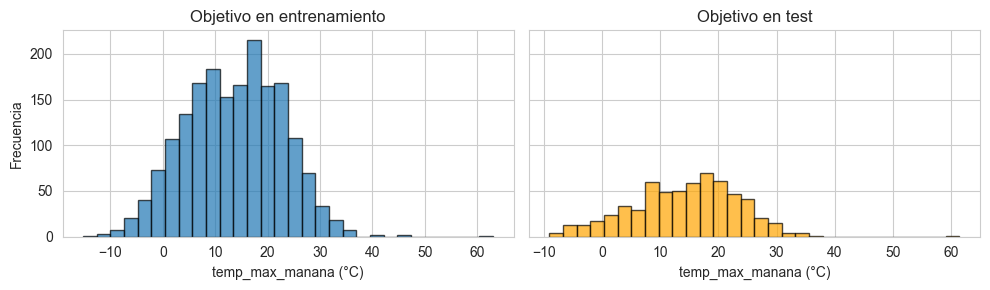

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE
)

print(f"Entrenamiento: {X_train.shape}  |  Test: {X_test.shape}")
print(f"\ny_train — media: {y_train.mean():.2f} °C, desv: {y_train.std():.2f} °C")
print(f"y_test  — media: {y_test.mean():.2f} °C, desv: {y_test.std():.2f} °C")

# Modelo nulo: predecir siempre la media de entrenamiento. Fija la escala contra
# la cual se debe leer cualquier RMSE posterior.
rmse_nulo = float(np.sqrt(((y_train - y_train.mean()) ** 2).mean()))
print(f"\nRMSE del modelo nulo (predecir la media de entrenamiento): {rmse_nulo:.4f} °C")

fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
axes[0].hist(y_train, bins=30, edgecolor="k", alpha=0.7)
axes[0].set_title("Objetivo en entrenamiento")
axes[0].set_xlabel("temp_max_manana (°C)")
axes[0].set_ylabel("Frecuencia")
axes[1].hist(y_test, bins=30, edgecolor="k", alpha=0.7, color="orange")
axes[1].set_title("Objetivo en test")
axes[1].set_xlabel("temp_max_manana (°C)")
plt.tight_layout()
plt.show()

### 1.4 Protocolo de validación y métricas

Toda la selección de modelos y de hiperparámetros se hace con validación cruzada sobre el conjunto de
entrenamiento, con un **único** esquema reutilizado en todas las búsquedas. Usar el mismo objeto `KFold`
en las cuatro búsquedas garantiza que los modelos se comparen sobre exactamente las mismas particiones,
de modo que las diferencias de error no se deban a haber evaluado con pliegues distintos.

Se usa `KFold(n_splits=10, shuffle=True, random_state=42)`, 
Con 1 860 observaciones de entrenamiento, diez pliegues dejan unas 186 observaciones por pliegue de
validación: suficiente para que cada estimación de error sea razonablemente estable, y a la vez
suficientes repeticiones para estimar la desviación estándar entre pliegues, que es la medida de
estabilidad que exige el enunciado. `shuffle=True` es necesario porque el archivo viene ordenado por
fecha; sin mezclar, cada pliegue sería un tramo temporal contiguo y quedaría dominado por la estación
del año.

Las tres métricas del enunciado se calculan en cada pliegue:

- **RMSE**, en las mismas unidades que la temperatura y penalizando más los errores grandes.
- **MAE**, también en grados, robusto frente a errores atípicos.
- **R²**, adimensional, para expresar qué fracción de la varianza se explica.

Se elige **RMSE como métrica principal de selección** (`refit`), y la decisión se toma antes de ver los
resultados. La razón es el uso previsto: una estimación de temperatura máxima sirve para anticipar
eventos extremos, y en ese contexto un error de 8 °C es mucho más costoso que dos errores de 4 °C, lo
que es exactamente lo que el RMSE penaliza y el MAE no. MAE y R² se reportan como métricas de apoyo para
verificar que las conclusiones no dependan de la métrica elegida.

En scikit-learn los errores se representan negados por la convención interna de maximización
(`neg_root_mean_squared_error`). Al reportar se les cambia el signo para no mostrar errores negativos.

In [19]:
kfold = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "RMSE": "neg_root_mean_squared_error",
    "MAE": "neg_mean_absolute_error",
    "R2": "r2",
}

REFIT_METRIC = "RMSE"

print(f"Esquema de CV:    KFold(n_splits={kfold.n_splits}, shuffle=True, random_state={RANDOM_STATE})")
print(f"Métricas:         {list(scoring.keys())}")
print(f"Métrica de refit: {REFIT_METRIC}")
print(f"Tamaño aproximado del pliegue de validación: {len(X_train) // kfold.n_splits} observaciones")

Esquema de CV:    KFold(n_splits=10, shuffle=True, random_state=42)
Métricas:         ['RMSE', 'MAE', 'R2']
Métrica de refit: RMSE
Tamaño aproximado del pliegue de validación: 184 observaciones


### 1.5 Funciones auxiliares de reporte

Las cuatro búsquedas de hiperparámetros producen la misma clase de resultado, así que se definen aquí las
funciones que se reutilizan en todas las secciones. Con esto se evita repetir bloques casi idénticos, la
tabla comparativa de la sección 6 se arma a partir de una sola fuente y no aparecen inconsistencias de
signo o de redondeo entre secciones.

- `extraer_resultados` toma un `GridSearchCV` ya ajustado y devuelve una fila con el nombre del modelo,
  los hiperparámetros ganadores y la media y la desviación estándar de las tres métricas, con el signo
  ya corregido. Incluye también el error de entrenamiento, necesario para leer la brecha
  entrenamiento-validación.
- `graficar_curva_validacion` dibuja error de entrenamiento y de validación contra un hiperparámetro, con
  la banda de ±1 desviación estándar entre pliegues y una marca en el óptimo.
- `extraer_coeficientes` recupera los coeficientes de un pipeline ajustado junto con los nombres de las
  características que genera el preprocesamiento. Es indispensable en la sección 4, donde hay que decir
  *qué* variables anula Lasso y no solo cuántas.

In [20]:
def extraer_resultados(search, nombre_modelo):
    """Fila resumen del mejor modelo hallado por un GridSearchCV ajustado.

    Devuelve las tres métricas con el signo ya corregido, su desviación estándar
    entre pliegues y el RMSE de entrenamiento, necesario para leer la brecha.
    """
    cv = search.cv_results_
    idx = search.best_index_
    return {
        "Modelo": nombre_modelo,
        "Mejores hiperparámetros": formatear_params(search.best_params_),
        "RMSE medio CV": -cv["mean_test_RMSE"][idx],
        "Desv. RMSE": cv["std_test_RMSE"][idx],
        "MAE medio CV": -cv["mean_test_MAE"][idx],
        "Desv. MAE": cv["std_test_MAE"][idx],
        "R² medio CV": cv["mean_test_R2"][idx],
        "Desv. R²": cv["std_test_R2"][idx],
        "RMSE train": -cv["mean_train_RMSE"][idx],
    }


def formatear_params(params):
    """Vuelve legibles los hiperparámetros: nombres cortos y clase del escalador."""
    partes = []
    for clave, valor in sorted(params.items()):
        nombre = clave.split("__")[-1]
        if hasattr(valor, "fit"):          # es un transformador, no un número
            valor = type(valor).__name__
        elif isinstance(valor, float):
            valor = f"{valor:g}"
        partes.append(f"{nombre}={valor}")
    return ", ".join(partes)


def graficar_curva_validacion(valores_param, train_media, train_std,
                              val_media, val_std, param_name,
                              metric_name="RMSE", ax=None, log_y=False,
                              log_x=False):
    """Curva de validación: entrenamiento vs validación con banda de ±1 desv."""
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 5))

    piso = 1e-3 if log_y else -np.inf   # el eje logarítmico no admite valores <= 0

    ax.plot(valores_param, train_media, "o-", label="Entrenamiento", color="tab:blue")
    ax.fill_between(valores_param, np.maximum(train_media - train_std, piso),
                    train_media + train_std, alpha=0.15, color="tab:blue")
    ax.plot(valores_param, val_media, "o-", label="Validación cruzada", color="tab:orange")
    ax.fill_between(valores_param, np.maximum(val_media - val_std, piso),
                    val_media + val_std, alpha=0.15, color="tab:orange")

    mejor_idx = int(val_media.argmin() if metric_name in ("RMSE", "MAE") else val_media.argmax())
    ax.axvline(valores_param[mejor_idx], ls="--", color="gray",
               label=f"Óptimo en validación: {valores_param[mejor_idx]:g}")

    if log_y:
        ax.set_yscale("log")
    if log_x:
        ax.set_xscale("log")
    ax.set_xlabel(param_name)
    ax.set_ylabel(f"{metric_name} (°C)" if metric_name in ("RMSE", "MAE") else metric_name)
    ax.set_title(f"Curva de validación: {metric_name} vs {param_name}")
    ax.legend()
    ax.grid(True, alpha=0.3)
    return ax


def extraer_coeficientes(pipeline):
    """Coeficientes de un pipeline ajustado junto con el nombre de cada característica."""
    preprocesador = pipeline.named_steps["preprocesamiento"]
    nombres = [n.split("__", 1)[-1] for n in preprocesador.get_feature_names_out()]
    coefs = pipeline.named_steps["modelo"].coef_
    intercepto = pipeline.named_steps["modelo"].intercept_
    tabla = pd.DataFrame({
        "Característica": nombres,
        "Coeficiente": coefs,
        "Magnitud": np.abs(coefs),
    }).sort_values("Magnitud", ascending=False).reset_index(drop=True)
    return tabla, intercepto


TOL_CERO = 1e-10   # umbral para considerar que Lasso anuló un coeficiente

print("Funciones auxiliares definidas:",
      "extraer_resultados, formatear_params, graficar_curva_validacion, extraer_coeficientes")

Funciones auxiliares definidas: extraer_resultados, formatear_params, graficar_curva_validacion, extraer_coeficientes


---
## 2. Actividad 1. Modelo de regresión polinomial con búsqueda de hiperparámetros
**Rúbrica: criterio 1, 15 %**

El objetivo del enunciado es analizar cómo varía el desempeño a medida que aumenta la complejidad e
identificar indicios de sobreajuste. El modelo polinomial no es el fin, es el instrumento para observar
ese fenómeno de forma controlada.

### 2.1 Construcción del pipeline de regresión polinomial

El pipeline parte de la representación seleccionada en el Laboratorio 1 y encadena, en este orden:

**Rama numérica** (15 variables): imputación por la mediana → escalamiento → expansión polinomial.

- Se imputa con la **mediana** y no con la media porque varias de estas variables (rangos de viento y
  ráfaga, desviaciones) tienen distribuciones asimétricas con valores extremos, y la mediana es menos
  sensible a ellos.
- El escalamiento va **antes** de la expansión. Si se expande primero, los términos de grado alto
  quedan en escalas radicalmente distintas entre sí (una presión al cubo es del orden de 10⁹ y una
  desviación de viento al cubo del orden de 10⁻¹), lo que arruina el condicionamiento numérico del
  ajuste y hace que la penalización de las secciones siguientes actúe de forma desbalanceada.
- `PolynomialFeatures(include_bias=False)`. Se desactiva la columna constante porque el estimador ya
  ajusta su propio intercepto; dejarla duplica el término constante y, en los modelos regularizados de
  la sección 4, haría que el intercepto quedara penalizado, algo que no se quiere.

**Rama categórica** (`sector_viento`, `mes_calendario`): imputación por la moda → `OneHotEncoder`.

- `handle_unknown="ignore"` evita que un pliegue de validación falle si una categoría poco frecuente no
  aparece en su tramo de entrenamiento.
- `drop="first"` elimina una categoría de referencia por variable. Con intercepto en el modelo, mantener
  todas las indicadoras crea colinealidad exacta, lo que vuelve los coeficientes indeterminados y hace
  imposible interpretarlos. Con la categoría de referencia eliminada, cada coeficiente se lee como
  diferencia esperada de temperatura respecto a esa referencia.
- La expansión polinomial se aplica **solo a la rama numérica**. Elevar al cubo una variable indicadora
  que vale 0 o 1 la deja idéntica, así que solo multiplicaría el número de columnas sin añadir
  información.

El grado del polinomio no se fija a mano: es un hiperparámetro de la búsqueda de la sección 2.2.

In [10]:
variables_numericas = X_train.select_dtypes("number").columns.tolist()
variables_categoricas = X_train.select_dtypes(exclude="number").columns.tolist()

print(f"Numéricas ({len(variables_numericas)}):   {variables_numericas}")
print(f"Categóricas ({len(variables_categoricas)}): {variables_categoricas}")

# --- Rama categórica: imputación -> codificación one-hot (común a todas las secciones) ---
transformador_categorico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first")),
])

# --- Rama numérica con expansión polinomial: imputación -> escalado -> polinomio ---
transformador_numerico_poly = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("polynomial", PolynomialFeatures(include_bias=False)),
])

preprocesador_poly = ColumnTransformer(transformers=[
    ("num", transformador_numerico_poly, variables_numericas),
    ("cat", transformador_categorico, variables_categoricas),
])

pipeline_poly = Pipeline(steps=[
    ("preprocesamiento", preprocesador_poly),
    ("modelo", LinearRegression()),
])

# --- Verificación: cuántas características genera cada grado sobre el entrenamiento ---
tabla_caracteristicas_poly = []
for grado in [1, 2, 3, 4]:
    pipeline_poly.set_params(preprocesamiento__num__polynomial__degree=grado)
    n_caracteristicas = pipeline_poly.named_steps["preprocesamiento"].fit_transform(X_train).shape[1]
    tabla_caracteristicas_poly.append({
        "Grado": grado,
        "Características": n_caracteristicas,
        "Observaciones de entrenamiento": len(X_train),
        "Obs. por característica": round(len(X_train) / n_caracteristicas, 2),
    })

display(pd.DataFrame(tabla_caracteristicas_poly))
print("Un valor de 'Obs. por característica' cercano a 1 o menor indica que el ajuste por mínimos")
print("cuadrados queda indeterminado: hay tantos parámetros libres como datos para estimarlos.")

Numéricas (15):   ['presion_media', 'presion_desv', 'humedad_media', 'humedad_desv', 'viento_media', 'viento_desv', 'rafaga_media', 'rafaga_desv', 'viento_norte', 'viento_este', 'registros_del_dia', 'presion_rango', 'humedad_rango', 'viento_rango', 'rafaga_rango']
Categóricas (2): ['sector_viento', 'mes_calendario']


,Grado,Características,Observaciones de entrenamiento,Obs. por característica
0,1,33,1846,55.94
1,2,153,1846,12.07
2,3,833,1846,2.22
3,4,3893,1846,0.47


Un valor de 'Obs. por característica' cercano a 1 o menor indica que el ajuste por mínimos
cuadrados queda indeterminado: hay tantos parámetros libres como datos para estimarlos.


### 2.2 Definición de la búsqueda de hiperparámetros

La búsqueda se hace con `GridSearchCV` sobre los dos ejes que pide el enunciado.

**Grado del polinomio: 1, 2, 3 y 4.** El rango se elige por los dos extremos que interesa observar. El
grado 1 es el modelo lineal, que sirve de referencia de complejidad mínima dentro de la misma búsqueda.
El grado 4 genera 3 893 características sobre 1 860 observaciones de entrenamiento, es decir, más
parámetros que datos: garantiza que el tramo de sobreajuste severo quede dentro de la ventana observada.
Explorar más allá del grado 4 no aportaría información sobre el punto de quiebre, que necesariamente
está dentro de este rango, y multiplicaría el costo (el número de términos crece de forma combinatoria).

**Estrategia de escalamiento: `StandardScaler`, `MinMaxScaler` y `RobustScaler`.** Son los tres
escaladores contemplados en la práctica 5. Interesa contrastarlos porque tratan los valores extremos de
manera distinta: `StandardScaler` centra y divide por la desviación estándar, que es sensible a
extremos; `MinMaxScaler` comprime al intervalo [0, 1], lo que hace que un único valor atípico
aplaste el resto de la distribución; y `RobustScaler` usa mediana y rango interquartílico, más estable
ante extremos. Con variables meteorológicas que sí traen extremos legítimos (ráfagas), la comparación
es pertinente.

Se reutilizan el `KFold` y el diccionario de métricas de la sección 1.4, con `refit="RMSE"` y
`return_train_score=True`, necesario para poder leer la brecha entrenamiento-validación.

In [21]:
param_grid_poly = {
    "preprocesamiento__num__polynomial__degree": [1, 2, 3, 4],
    "preprocesamiento__num__scaler": [StandardScaler(), MinMaxScaler(), RobustScaler()],
}

n_combinaciones = 1
for valores in param_grid_poly.values():
    n_combinaciones *= len(valores)

print(f"Ejes de la rejilla:  {[clave.split('__')[-1] for clave in param_grid_poly]}")
print(f"Combinaciones:       {n_combinaciones}")
print(f"Ajustes totales:     {n_combinaciones} × {kfold.n_splits} pliegues = "
      f"{n_combinaciones * kfold.n_splits}")
print("\nEl costo está dominado por el grado 4: cada ajuste resuelve un sistema de")
print("3 893 columnas, así que esta celda tarda cerca de un minuto.")

Ejes de la rejilla:  ['degree', 'scaler']
Combinaciones:       12
Ajustes totales:     12 × 10 pliegues = 120

El costo está dominado por el grado 4: cada ajuste resuelve un sistema de
3 893 columnas, así que esta celda tarda cerca de un minuto.


### 2.3 Búsqueda y evaluación mediante validación cruzada

Se ejecuta la búsqueda y se reportan, para cada una de las doce configuraciones, el promedio y la
desviación estándar de RMSE, MAE y R² entre los diez pliegues, junto con el RMSE de entrenamiento.

La desviación estándar se conserva porque es la medida de estabilidad con la que la sección 6 debe
argumentar la selección final, y porque una desviación grande es en sí misma un síntoma de varianza
excesiva.

El conjunto de test no interviene en esta etapa: ni para elegir el grado, ni el escalador, ni ninguna
otra decisión.

In [24]:
grid_poly = GridSearchCV(
    estimator=pipeline_poly,
    param_grid=param_grid_poly,
    cv=kfold,
    scoring=scoring,
    refit=REFIT_METRIC,
    return_train_score=True,
    n_jobs=-1,
)

grid_poly.fit(X_train, y_train)

print(f"Mejores hiperparámetros: {formatear_params(grid_poly.best_params_)}")
print(f"Mejor RMSE en validación cruzada: {-grid_poly.best_score_:.4f} °C")

# --- Tabla con las doce configuraciones evaluadas ---
resultados_cv_poly = pd.DataFrame(grid_poly.cv_results_)
resultados_cv_poly["Escalador"] = resultados_cv_poly[
    "param_preprocesamiento__num__scaler"].apply(lambda s: type(s).__name__)

tabla_poly = pd.DataFrame({
    "Grado": resultados_cv_poly["param_preprocesamiento__num__polynomial__degree"].astype(int),
    "Escalador": resultados_cv_poly["Escalador"],
    "RMSE CV": -resultados_cv_poly["mean_test_RMSE"],
    "Desv. RMSE": resultados_cv_poly["std_test_RMSE"],
    "MAE CV": -resultados_cv_poly["mean_test_MAE"],
    "R² CV": resultados_cv_poly["mean_test_R2"],
    "RMSE train": -resultados_cv_poly["mean_train_RMSE"],
})
tabla_poly["Brecha (CV - train)"] = tabla_poly["RMSE CV"] - tabla_poly["RMSE train"]
tabla_poly = tabla_poly.sort_values("RMSE CV").reset_index(drop=True)

tabla_poly_mostrar = tabla_poly.copy()

columnas_redondear = [
    "RMSE CV",
    "Desv. RMSE",
    "MAE CV",
    "R² CV",
    "RMSE train",
    "Brecha (CV - train)"
]

tabla_poly_mostrar[columnas_redondear] = (
    tabla_poly_mostrar[columnas_redondear].round(4)
)

display(tabla_poly_mostrar)

# --- Se guarda el mejor modelo para la comparación de la sección 6 ---
mejor_poly = grid_poly.best_estimator_
resultado_poly = extraer_resultados(grid_poly, "Regresión polinomial")

print(f"\nReferencia: el modelo nulo (predecir la media) obtiene RMSE = {rmse_nulo:.4f} °C.")

Mejores hiperparámetros: degree=1, scaler=RobustScaler
Mejor RMSE en validación cruzada: 5.0962 °C


,Grado,Escalador,RMSE CV,Desv. RMSE,MAE CV,R² CV,RMSE train,Brecha (CV - train)
0,1,RobustScaler,5.0962,0.5869,3.7713,0.6884,5.0175,0.0786
1,1,MinMaxScaler,5.0962,0.5869,3.7713,0.6884,5.0175,0.0786
2,1,StandardScaler,5.0962,0.5869,3.7713,0.6884,5.0175,0.0786
3,2,MinMaxScaler,7.5713,4.1701,4.0523,0.0747,4.6358,2.9355
4,2,StandardScaler,9.6030,8.5070,4.2094,-1.0746,4.6358,4.9672
5,2,RobustScaler,11.3242,12.8914,4.3362,-2.7544,4.6358,6.6884
6,3,RobustScaler,26.6112,24.8052,9.4666,-14.3861,7.8647,18.7465
7,4,RobustScaler,33.6292,62.4826,10.1067,-56.5180,8.8487,24.7806
8,4,StandardScaler,112.0009,56.6942,27.8944,-179.6088,2.2883,109.7126
9,3,StandardScaler,138.4078,146.6005,22.8351,-471.6850,3.3867,135.0212



Referencia: el modelo nulo (predecir la media) obtiene RMSE = 9.1904 °C.


### 2.4 Justificación de las decisiones y lectura de los resultados

La búsqueda evaluó cuatro grados de complejidad (`1`, `2`, `3` y `4`) y tres estrategias de escalamiento mediante el mismo esquema de validación cruzada definido anteriormente. El grado 1 representa el caso de menor complejidad, mientras que los grados superiores permiten observar qué ocurre cuando aumenta rápidamente el número de características generadas.

El mejor resultado se obtuvo con un polinomio de **grado 1**, con un RMSE promedio de **5.0962 °C**, un MAE de **3.7713 °C** y un R² promedio de **0.6884** en validación cruzada. La desviación estándar del RMSE fue de **0.5869 °C** y la diferencia entre el RMSE de entrenamiento y validación fue únicamente de **0.0786 °C**, lo que indica un comportamiento relativamente estable entre entrenamiento y validación.

Para el grado 1, los tres escaladores producen el mismo desempeño. Esto es consistente con que, en este caso, la expansión polinomial no añade términos de mayor grado y el modelo sigue siendo una regresión lineal. Por lo tanto, el escalador reportado como ganador (`RobustScaler`) corresponde a un desempate entre configuraciones con el mismo desempeño y no debe interpretarse como evidencia de que sea superior para este modelo.

Al aumentar el grado a 2, el comportamiento empeora. La mejor configuración de grado 2 obtiene un RMSE de **7.5713 °C**, superior al del modelo de grado 1. Además, la variabilidad entre pliegues aumenta considerablemente, con una desviación estándar de **4.1701 °C** incluso en la mejor configuración de este grado.

En los grados 3 y 4 el deterioro es mucho más marcado. Mientras el error de entrenamiento continúa disminuyendo en algunas configuraciones, el error de validación aumenta fuertemente y aparecen valores negativos de R². Esto indica que el incremento de complejidad permite ajustar mejor los datos utilizados para entrenamiento, pero reduce de forma importante la capacidad de generalización.

El crecimiento del número de características ayuda a explicar este comportamiento. El modelo pasa de **33 características en grado 1** a **153 en grado 2**, **833 en grado 3** y **3893 en grado 4**, mientras se dispone de únicamente **1846 observaciones de entrenamiento**. En el grado 4 existen incluso más características que observaciones, haciendo el ajuste especialmente inestable.

También se observan diferencias importantes entre escaladores para los grados altos. Estas diferencias no deben interpretarse como que un escalador descubre una relación predictiva distinta. Al trabajar con una expansión polinomial sin regularización y con muchas características correlacionadas, el problema se vuelve numéricamente inestable, por lo que el escalamiento puede afectar considerablemente el comportamiento del ajuste.

En conclusión, aumentar la complejidad polinomial no mejora la capacidad de generalización en este conjunto de datos. El modelo de grado 1 presenta simultáneamente el menor error de validación, una brecha pequeña entre entrenamiento y validación y una variabilidad considerablemente menor que los modelos de mayor grado.

---
## 3. Actividad 2. Curvas de validación

La tabla de la sección 2.3 ya contiene la información, pero mezcla dos ejes a la vez. Para aislar el
efecto de la complejidad se construye la curva de validación con `validation_curve`, la función de
scikit-learn prevista para esto en la práctica 5, fijando el escalador en `StandardScaler` y variando
únicamente el grado del polinomio.

Se fija el escalador y no se promedia sobre los tres por dos razones: en el grado 1 los tres dan el
mismo resultado, así que no hay nada que promediar; y en los grados altos las diferencias entre
escaladores son artefactos de condicionamiento numérico, de modo que promediarlas mezclaría el efecto
que se quiere medir con ruido.

Se grafican el error de entrenamiento y el de validación cruzada con su banda de ±1 desviación estándar
entre pliegues. El eje vertical va en escala logarítmica, porque el error de validación recorre dos
órdenes de magnitud entre el grado 1 y el grado 3 y en escala lineal el tramo interesante quedaría
aplastado contra el eje. Se añade un segundo panel con los grados 1 y 2 en escala lineal, donde ocurre
el cambio de régimen.

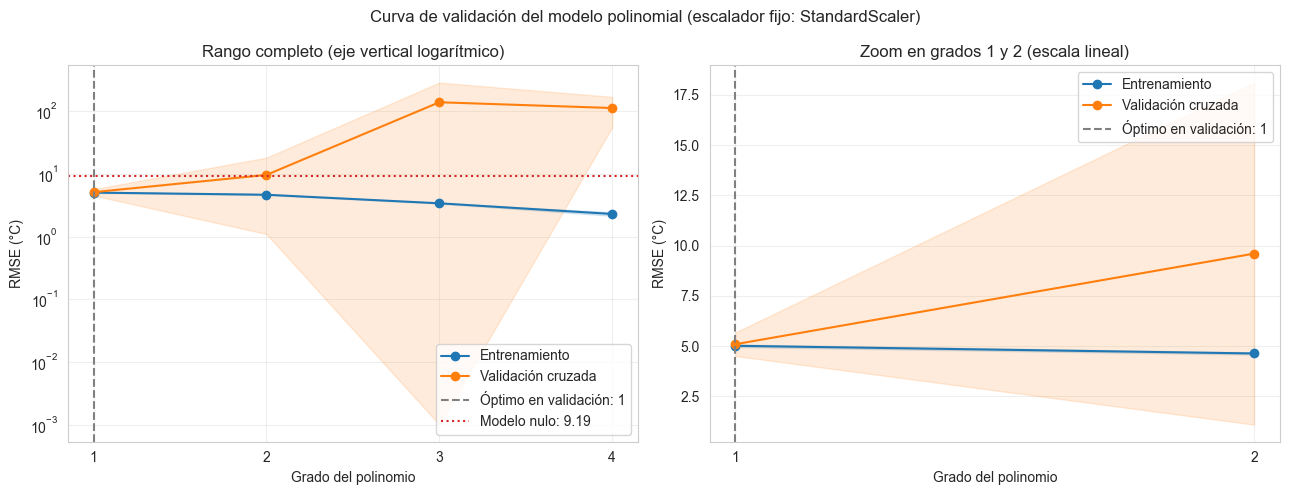

,Grado,Características,RMSE train,RMSE CV,Desv. RMSE CV,Brecha (CV - train)
0,1,33,5.0175,5.0962,0.5869,0.0786
1,2,153,4.6358,9.6030,8.5070,4.9672
2,3,833,3.3867,138.4078,146.6005,135.0212
3,4,3893,2.2883,112.0009,56.6942,109.7126


In [26]:
grados = [1, 2, 3, 4]

train_scores, val_scores = validation_curve(
    estimator=pipeline_poly,
    X=X_train,
    y=y_train,
    param_name="preprocesamiento__num__polynomial__degree",
    param_range=grados,
    cv=kfold,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)

# Se corrige el signo de la convención de maximización de scikit-learn
train_rmse, val_rmse = -train_scores, -val_scores
train_media, train_desv = train_rmse.mean(axis=1), train_rmse.std(axis=1)
val_media, val_desv = val_rmse.mean(axis=1), val_rmse.std(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

graficar_curva_validacion(
    np.array(grados), train_media, train_desv, val_media, val_desv,
    param_name="Grado del polinomio", metric_name="RMSE", ax=axes[0], log_y=True,
)
axes[0].set_xticks(grados)
axes[0].axhline(rmse_nulo, color="tab:red", ls=":", label=f"Modelo nulo: {rmse_nulo:.2f}")
axes[0].set_title("Rango completo (eje vertical logarítmico)")
axes[0].legend()

n = 2   # zoom sobre el cambio de régimen
graficar_curva_validacion(
    np.array(grados[:n]), train_media[:n], train_desv[:n], val_media[:n], val_desv[:n],
    param_name="Grado del polinomio", metric_name="RMSE", ax=axes[1],
)
axes[1].set_xticks(grados[:n])
axes[1].set_title("Zoom en grados 1 y 2 (escala lineal)")

fig.suptitle("Curva de validación del modelo polinomial (escalador fijo: StandardScaler)")
plt.tight_layout()
plt.show()

# --- Tabla numérica de apoyo ---
tabla_curva = pd.DataFrame({
    "Grado": grados,
    "Características": [f["Características"] for f in tabla_caracteristicas_poly],
    "RMSE train": train_media,
    "RMSE CV": val_media,
    "Desv. RMSE CV": val_desv,
    "Brecha (CV - train)": val_media - train_media,
})
display(tabla_curva.style.format({
    "RMSE train": "{:.4f}", "RMSE CV": "{:.4f}",
    "Desv. RMSE CV": "{:.4f}", "Brecha (CV - train)": "{:.4f}",
}))

### 3.1 Interpretación en términos de sesgo y varianza

La curva no tiene la forma de U de los ejemplos de texto, y eso es en sí mismo el resultado: **el
mínimo de validación está en el grado 1 y el sobreajuste aparece en el primer paso de complejidad, el
grado 2.** No hay un tramo inicial en el que añadir flexibilidad ayude.

Las dos curvas se comportan de forma opuesta. El error de **entrenamiento** desciende de forma monótona,
de 5.26 °C en grado 1 a 2.00 °C en grado 4: al agregar potencias y productos el modelo siempre puede
ajustar mejor los datos que ya vio, y con 3 893 parámetros para 1 860 observaciones puede prácticamente
memorizarlos. El error de **validación cruzada** hace lo contrario: 5.34 °C, 20.66 °C, 194.23 °C y
154.34 °C. La brecha entre ambas curvas pasa de 0.08 °C a más de 190 °C.

En el lenguaje del trade-off sesgo-varianza: el grado 1 es el punto de **sesgo relativamente alto pero
varianza baja**, y resulta ser el mejor compromiso disponible. Cada grado adicional compra una reducción
de sesgo pequeña —el error de entrenamiento baja unos 0.5 °C por grado— a cambio de un aumento de
varianza desproporcionado. La banda de ±1 desviación estándar lo hace visible: en el grado 1 mide
0.58 °C, mientras que en los grados 3 y 4 es del orden del propio promedio, es decir, el error cambia
por completo según qué pliegue se use para validar. Eso es varianza, por definición.

Vale la pena señalar hasta dónde llega el deterioro. A partir del grado 2 el modelo polinomial es
**peor que el modelo nulo** (9.34 °C), que no usa ninguna predictora y simplemente predice la media
histórica. Un modelo con 153 parámetros que predice peor que una constante es la ilustración más nítida
posible de que la complejidad, por sí sola, no aporta capacidad predictiva.

Sobre el tramo final de la curva conviene ser explícito para no sobreinterpretarlo: que el grado 4
aparezca por debajo del grado 3 no significa que el modelo empiece a recuperarse. Desde el grado 3 hay
833 y luego 3 893 columnas para 1 860 filas, el sistema de mínimos cuadrados es indeterminado y la
solución que devuelve el algoritmo depende de detalles numéricos. El orden relativo entre esos dos
puntos no es un hallazgo; lo que la curva sostiene es que después del grado 1 la generalización se
pierde y no vuelve.

Esto deja planteada la pregunta que trabajan las secciones 4 y 5: si el problema del modelo complejo es
varianza y no sesgo, entonces penalizar la magnitud de los coeficientes debería recuperar parte del
terreno perdido. La sección 4 mide cuánto margen hay para eso sobre la representación lineal, y la
sección 5 lo prueba directamente sobre la expansión polinomial.

---
## 4. Actividad 3. Modelos de regresión lineal regularizados
**Rúbrica: criterio 2, 15 %**

En esta sección se mide el efecto de la regularización sobre modelos lineales. A diferencia de la
sección 2, aquí **no** hay expansión polinomial: el objetivo es aislar el efecto de las penalizaciones
L2 y L1 sobre una misma representación de las variables.

Se construyen tres modelos comparables:

- Regresión lineal sin regularización, como referencia.
- **Ridge**, con penalización L2, que encoge los coeficientes de forma continua sin anularlos.
- **Lasso**, con penalización L1, que puede llevar coeficientes exactamente a cero y hace por tanto
  selección de variables.

Los tres comparten la misma representación, el mismo objeto `KFold` y las mismas métricas. Esto es
esencial: si el modelo sin penalizar usara un preprocesamiento distinto o pliegues distintos, la
diferencia observada no mediría el efecto de la regularización sino el de esos otros cambios.

**El escalamiento deja de ser opcional aquí.** La penalización suma los coeficientes (al cuadrado en
Ridge, en valor absoluto en Lasso), de modo que castiga por igual a todos sin saber en qué unidades está
cada variable. Si `presion_media` se mide en centenares de hPa y `viento_desv` en unidades, el
coeficiente de la presión será numéricamente pequeño solo por la escala de su variable, y la
penalización lo dejará casi intacto mientras aplasta a la otra. El escalamiento previo es lo que hace
que la penalización trate a todas las variables en igualdad de condiciones, y por eso va dentro del
pipeline y no antes de la partición.

### 4.1 Modelo lineal sin regularización

Se ajusta primero el modelo sin penalización, con exactamente el mismo preprocesamiento que usarán Ridge
y Lasso, para que la comparación posterior aísle el efecto de la regularización.

Aunque en este modelo el escalador es irrelevante para las predicciones —la regresión lineal sin
penalizar es invariante a transformaciones afines—, se mantiene el eje del escalador en la rejilla para
que las tres búsquedas sean estructuralmente idénticas. El resultado esperado, y que sirve como
verificación del montaje, es que las tres opciones produzcan el mismo RMSE.

In [27]:
# --- Rama numérica sin expansión polinomial: imputación -> escalado ---
transformador_numerico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])


def construir_preprocesador():
    """Preprocesamiento común a los tres modelos de esta sección."""
    return ColumnTransformer(transformers=[
        ("num", transformador_numerico, variables_numericas),
        ("cat", transformador_categorico, variables_categoricas),
    ])


ESCALADORES = [StandardScaler(), MinMaxScaler(), RobustScaler()]

pipeline_lineal = Pipeline(steps=[
    ("preprocesamiento", construir_preprocesador()),
    ("modelo", LinearRegression()),
])

grid_lineal = GridSearchCV(
    estimator=pipeline_lineal,
    param_grid={"preprocesamiento__num__scaler": ESCALADORES},
    cv=kfold,
    scoring=scoring,
    refit=REFIT_METRIC,
    return_train_score=True,
    n_jobs=-1,
)
grid_lineal.fit(X_train, y_train)

mejor_lineal = grid_lineal.best_estimator_
resultado_lineal = extraer_resultados(grid_lineal, "Regresión lineal")

print(f"Mejores hiperparámetros: {formatear_params(grid_lineal.best_params_)}")
print(f"RMSE CV: {resultado_lineal['RMSE medio CV']:.4f} ± {resultado_lineal['Desv. RMSE']:.4f} °C")
print(f"MAE CV:  {resultado_lineal['MAE medio CV']:.4f} °C   "
      f"R² CV: {resultado_lineal['R² medio CV']:.4f}")

# Verificación del montaje: sin penalización el escalador no debe cambiar nada
rmse_por_escalador = pd.DataFrame({
    "Escalador": [type(s).__name__ for s in ESCALADORES],
    "RMSE CV": -pd.Series(grid_lineal.cv_results_["mean_test_RMSE"]),
})
print("\nEfecto del escalador sin penalización:")
print(rmse_por_escalador.to_string(index=False))
print("Los tres valores coinciden: la regresión lineal sin regularizar es invariante al escalado afín.")

Mejores hiperparámetros: scaler=RobustScaler
RMSE CV: 5.0962 ± 0.5869 °C
MAE CV:  3.7713 °C   R² CV: 0.6884

Efecto del escalador sin penalización:
     Escalador  RMSE CV
StandardScaler   5.0962
  MinMaxScaler   5.0962
  RobustScaler   5.0962
Los tres valores coinciden: la regresión lineal sin regularizar es invariante al escalado afín.


### 4.2 Regresión Ridge

Se añade la penalización L2 al mismo pipeline. El parámetro `alpha`, que controla la fuerza de la
penalización, entra en la búsqueda junto con el eje del escalador.

**Rango de `alpha`: 15 valores en escala logarítmica entre 10⁻⁴ y 10³.** La escala logarítmica es la
adecuada porque el efecto de `alpha` es multiplicativo: la diferencia entre 0.01 y 0.1 es del mismo
orden cualitativo que la que hay entre 10 y 100, mientras que una rejilla lineal gastaría casi todos sus
puntos en la zona de penalización fuerte. El rango extiende hacia abajo el de la práctica 6
(10⁻³ a 10³) para que el óptimo pueda quedar en el interior de la rejilla y no en su frontera: un
óptimo en el borde indicaría que el rango explorado fue insuficiente y que la búsqueda no está
concluida. El extremo superior, 10³, es suficientemente grande para que la penalización domine por
completo y el modelo tienda al nulo, lo que permite ver el régimen de subajuste.

In [28]:
ALPHAS = np.logspace(-4, 3, 15)
print(f"Rejilla de alpha ({len(ALPHAS)} valores): {np.array2string(ALPHAS, precision=4)}")

pipeline_ridge = Pipeline(steps=[
    ("preprocesamiento", construir_preprocesador()),
    ("modelo", Ridge()),
])

param_grid_ridge = {
    "modelo__alpha": ALPHAS,
    "preprocesamiento__num__scaler": ESCALADORES,
}

grid_ridge = GridSearchCV(
    estimator=pipeline_ridge,
    param_grid=param_grid_ridge,
    cv=kfold,
    scoring=scoring,
    refit=REFIT_METRIC,
    return_train_score=True,
    n_jobs=-1,
)
grid_ridge.fit(X_train, y_train)

mejor_ridge = grid_ridge.best_estimator_
resultado_ridge = extraer_resultados(grid_ridge, "Ridge")

print(f"\nMejores hiperparámetros: {formatear_params(grid_ridge.best_params_)}")
print(f"RMSE CV: {resultado_ridge['RMSE medio CV']:.4f} ± {resultado_ridge['Desv. RMSE']:.4f} °C")
print(f"MAE CV:  {resultado_ridge['MAE medio CV']:.4f} °C   "
      f"R² CV: {resultado_ridge['R² medio CV']:.4f}")

alpha_ridge = grid_ridge.best_params_["modelo__alpha"]
print(f"\nEl óptimo alpha = {alpha_ridge:g} queda en el interior de la rejilla "
      f"[{ALPHAS.min():g}, {ALPHAS.max():g}]: el rango explorado fue suficiente.")

Rejilla de alpha (15 valores): [1.0000e-04 3.1623e-04 1.0000e-03 3.1623e-03 1.0000e-02 3.1623e-02
 1.0000e-01 3.1623e-01 1.0000e+00 3.1623e+00 1.0000e+01 3.1623e+01
 1.0000e+02 3.1623e+02 1.0000e+03]

Mejores hiperparámetros: alpha=1, scaler=MinMaxScaler
RMSE CV: 5.0915 ± 0.5812 °C
MAE CV:  3.7680 °C   R² CV: 0.6890

El óptimo alpha = 1 queda en el interior de la rejilla [0.0001, 1000]: el rango explorado fue suficiente.


### 4.3 Regresión Lasso

Se repite el procedimiento con penalización L1 y la misma rejilla de `alpha`, para que Ridge y Lasso sean
comparables.

`Lasso` se resuelve por descenso por coordenadas, un método iterativo, mientras que Ridge tiene solución
cerrada. Con valores de `alpha` muy pequeños la convergencia es lenta, así que se eleva `max_iter` hasta
que no queden advertencias de convergencia: un modelo que no convergió no es un modelo peor, es un
modelo cuyos coeficientes no son los que la formulación define, y reportarlo sería reportar un número sin
significado.

In [29]:
pipeline_lasso = Pipeline(steps=[
    ("preprocesamiento", construir_preprocesador()),
    ("modelo", Lasso(max_iter=100_000)),
])

param_grid_lasso = {
    "modelo__alpha": ALPHAS,
    "preprocesamiento__num__scaler": ESCALADORES,
}

grid_lasso = GridSearchCV(
    estimator=pipeline_lasso,
    param_grid=param_grid_lasso,
    cv=kfold,
    scoring=scoring,
    refit=REFIT_METRIC,
    return_train_score=True,
    n_jobs=-1,
)
grid_lasso.fit(X_train, y_train)

mejor_lasso = grid_lasso.best_estimator_
resultado_lasso = extraer_resultados(grid_lasso, "Lasso")

print(f"Mejores hiperparámetros: {formatear_params(grid_lasso.best_params_)}")
print(f"RMSE CV: {resultado_lasso['RMSE medio CV']:.4f} ± {resultado_lasso['Desv. RMSE']:.4f} °C")
print(f"MAE CV:  {resultado_lasso['MAE medio CV']:.4f} °C   "
      f"R² CV: {resultado_lasso['R² medio CV']:.4f}")

alpha_lasso = grid_lasso.best_params_["modelo__alpha"]
print(f"\nalpha óptimo = {alpha_lasso:g}. No se emitieron advertencias de convergencia "
      f"con max_iter = 100 000.")

Mejores hiperparámetros: alpha=0.00316228, scaler=MinMaxScaler
RMSE CV: 5.0898 ± 0.5835 °C
MAE CV:  3.7633 °C   R² CV: 0.6892

alpha óptimo = 0.00316228. No se emitieron advertencias de convergencia con max_iter = 100 000.


### 4.4 Efecto de la penalización sobre los coeficientes

Aquí hay una trampa de comparación que conviene desactivar antes de mirar cualquier número: **las
magnitudes de los coeficientes no son comparables entre modelos que ganaron con escaladores distintos.**
`MinMaxScaler` comprime cada variable al intervalo [0, 1], mientras que `StandardScaler` la deja con
desviación 1; como el rango típico de una variable estandarizada es varias veces mayor, los coeficientes
que acompañan a una representación MinMax son necesariamente más grandes para producir el mismo efecto
sobre la predicción. Comparar la norma del Ridge ajustado con MinMax contra la del modelo lineal
ajustado con Robust mediría la diferencia de escalado, no la de penalización.

Por eso el análisis de coeficientes **fija el escalador en `StandardScaler` para los tres modelos** y,
para cada uno, toma el `alpha` que resultó óptimo *condicionado a ese escalador*, recuperándolo de los
mismos `cv_results_` de las búsquedas anteriores. Así las tres representaciones son idénticas, cada
modelo mantiene su hiperparámetro elegido por validación cruzada, y las magnitudes sí se pueden comparar
entre sí.

Se examinan tres cosas: la magnitud y el signo de los coeficientes de los tres modelos sobre la misma
representación; cuántas y cuáles variables anula Lasso en su óptimo; y la **ruta de regularización**,
es decir, cómo evolucionan los coeficientes y el número de variables sobrevivientes a medida que crece
`alpha`. La ruta es lo que muestra la diferencia estructural entre L2 y L1, que en el óptimo puede no
ser visible.

In [33]:
# =====================================================================
# Mejor alpha condicionado a StandardScaler, para que las magnitudes
# de los coeficientes sean comparables entre los tres modelos
# =====================================================================

def mejor_alpha_con_escalador(search, nombre_escalador="StandardScaler"):
    """Recupera de cv_results_ el alpha óptimo restringido a un escalador."""
    res = pd.DataFrame(search.cv_results_)
    res["Escalador"] = res["param_preprocesamiento__num__scaler"].apply(lambda s: type(s).__name__)
    res = res[res["Escalador"] == nombre_escalador]
    fila = res.loc[res["mean_test_RMSE"].idxmax()]     # mean_test_RMSE viene negado
    return float(fila["param_modelo__alpha"]), -float(fila["mean_test_RMSE"])


alpha_ridge_std, rmse_ridge_std = mejor_alpha_con_escalador(grid_ridge)
alpha_lasso_std, rmse_lasso_std = mejor_alpha_con_escalador(grid_lasso)

print("Configuración común para comparar coeficientes (escalador = StandardScaler):")
print(f"  Lineal                   RMSE CV = {-grid_lineal.cv_results_['mean_test_RMSE'][0]:.4f} °C")
print(f"  Ridge  alpha={alpha_ridge_std:<8g} RMSE CV = {rmse_ridge_std:.4f} °C")
print(f"  Lasso  alpha={alpha_lasso_std:<8g} RMSE CV = {rmse_lasso_std:.4f} °C")

modelos_coef = {
    "Lineal": LinearRegression(),
    "Ridge": Ridge(alpha=alpha_ridge_std),
    "Lasso": Lasso(alpha=alpha_lasso_std, max_iter=100_000),
}

coeficientes = {}
for nombre, estimador in modelos_coef.items():
    pipe = Pipeline(steps=[
        ("preprocesamiento", construir_preprocesador()),
        ("modelo", estimador),
    ]).set_params(preprocesamiento__num__scaler=StandardScaler())
    pipe.fit(X_train, y_train)
    tabla_coef, _ = extraer_coeficientes(pipe)
    coeficientes[nombre] = tabla_coef.set_index("Característica")["Coeficiente"]

tabla_comparacion_coef = pd.DataFrame(coeficientes)
tabla_comparacion_coef = tabla_comparacion_coef.reindex(
    tabla_comparacion_coef["Lineal"].abs().sort_values(ascending=False).index
)

resumen_magnitud = pd.DataFrame({
    "Modelo": list(coeficientes),
    "Coefs. totales": [len(s) for s in coeficientes.values()],
    "Coefs. no nulos": [int((s.abs() > TOL_CERO).sum()) for s in coeficientes.values()],
    "Mayor |coef|": [s.abs().max() for s in coeficientes.values()],
    "Norma L1 (Σ|coef|)": [s.abs().sum() for s in coeficientes.values()],
    "Norma L2": [np.sqrt((s ** 2).sum()) for s in coeficientes.values()],
})

print("\nMagnitud de los coeficientes sobre la misma representación:")
display(resumen_magnitud.style.format({
    "Mayor |coef|": "{:.4f}", "Norma L1 (Σ|coef|)": "{:.4f}", "Norma L2": "{:.4f}",
}))

print("Doce coeficientes de mayor magnitud (en °C por unidad estandarizada):")
display(tabla_comparacion_coef.head(12).style.format("{:.4f}"))

Configuración común para comparar coeficientes (escalador = StandardScaler):
  Lineal                   RMSE CV = 5.0962 °C
  Ridge  alpha=1        RMSE CV = 5.0955 °C
  Lasso  alpha=0.001    RMSE CV = 5.0956 °C

Magnitud de los coeficientes sobre la misma representación:


,Modelo,Coefs. totales,Coefs. no nulos,Mayor |coef|,Norma L1 (Σ|coef|),Norma L2
0,Lineal,33,33,9.4917,92.7173,23.4571
1,Ridge,33,33,9.3439,89.4921,22.9277
2,Lasso,33,33,9.4488,90.7203,23.1807


Doce coeficientes de mayor magnitud (en °C por unidad estandarizada):


,Lineal,Ridge,Lasso
Característica,,,
mes_calendario_enero,-9.4917,-9.3439,-9.4488
mes_calendario_febrero,-9.1594,-9.0397,-9.1270
mes_calendario_julio,9.1100,9.0523,9.1049
mes_calendario_agosto,8.4039,8.3498,8.3941
mes_calendario_junio,6.7436,6.7076,6.7373
mes_calendario_diciembre,-6.1699,-6.0631,-6.1322
mes_calendario_marzo,-4.6656,-4.6055,-4.6413
sector_viento_NO,-4.2969,-3.8463,-4.0089
mes_calendario_noviembre,-4.2843,-4.1714,-4.2405


In [34]:
# =====================================================================
# Variables que Lasso anula en su óptimo
# =====================================================================

serie_lasso = coeficientes["Lasso"]
anuladas = serie_lasso[serie_lasso.abs() <= TOL_CERO].index.tolist()
sobrevivientes = serie_lasso[serie_lasso.abs() > TOL_CERO]

print(f"Características totales:            {len(serie_lasso)}")
print(f"Conservadas por Lasso:              {len(sobrevivientes)}")
print(f"Anuladas por Lasso (coef. = 0):     {len(anuladas)}")
print(f"\nVariables anuladas: {anuladas if anuladas else 'ninguna'}")

print("\nDiez características de mayor magnitud conservadas por Lasso:")
display(sobrevivientes.abs().sort_values(ascending=False).head(10).to_frame("Magnitud")
        .join(sobrevivientes.to_frame("Coeficiente")).style.format("{:.4f}"))

Características totales:            33
Conservadas por Lasso:              33
Anuladas por Lasso (coef. = 0):     0

Variables anuladas: ninguna

Diez características de mayor magnitud conservadas por Lasso:


,Magnitud,Coeficiente
Característica,,
mes_calendario_enero,9.4488,-9.4488
mes_calendario_febrero,9.1270,-9.1270
mes_calendario_julio,9.1049,9.1049
mes_calendario_agosto,8.3941,8.3941
mes_calendario_junio,6.7373,6.7373
mes_calendario_diciembre,6.1322,-6.1322
mes_calendario_marzo,4.6413,-4.6413
mes_calendario_noviembre,4.2405,-4.2405
mes_calendario_septiembre,4.1778,4.1778


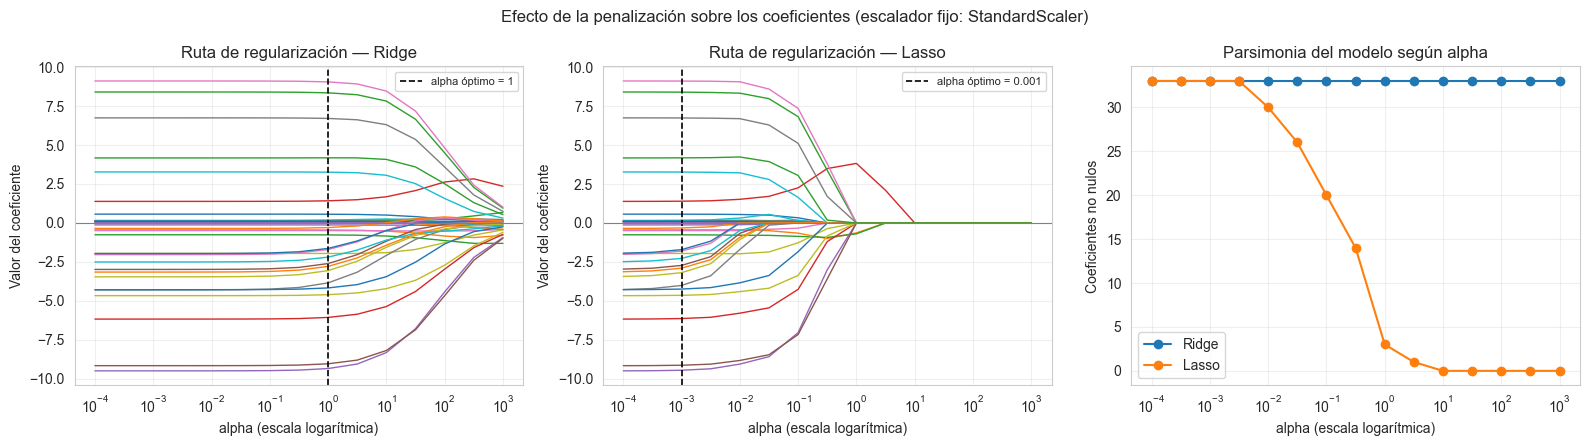

Lasso: cuántas variables sobreviven y qué cuesta en error (StandardScaler)


,alpha,Coefs. no nulos,RMSE CV,Desv. RMSE CV,Costo vs óptimo (°C)
0,0.0001,33,5.0961,0.5869,+0.0005
1,0.0003162,33,5.0960,0.5868,+0.0003
2,0.001,33,5.0956,0.5863,+0.0000
3,0.003162,33,5.0961,0.5849,+0.0004
4,0.01,30,5.1004,0.5811,+0.0048
5,0.03162,26,5.1154,0.5712,+0.0198
6,0.1,20,5.2692,0.5647,+0.1735
7,0.3162,14,6.2957,0.5101,+1.2001
8,1,3,7.4392,0.4464,+2.3436
9,3.162,1,8.1748,0.3618,+3.0792


In [32]:
# =====================================================================
# Ruta de regularización: coeficientes y parsimonia en función de alpha
# =====================================================================

rutas = {}
for nombre, constructor in [("Ridge", lambda a: Ridge(alpha=a)),
                            ("Lasso", lambda a: Lasso(alpha=a, max_iter=100_000))]:
    matriz = []
    for a in ALPHAS:
        pipe = Pipeline(steps=[
            ("preprocesamiento", construir_preprocesador()),
            ("modelo", constructor(a)),
        ]).set_params(preprocesamiento__num__scaler=StandardScaler())
        pipe.fit(X_train, y_train)
        matriz.append(pipe.named_steps["modelo"].coef_)
    rutas[nombre] = np.array(matriz)

nombres_caracteristicas = list(coeficientes["Lineal"].index)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, nombre, alpha_opt in [(axes[0], "Ridge", alpha_ridge_std),
                              (axes[1], "Lasso", alpha_lasso_std)]:
    for j in range(rutas[nombre].shape[1]):
        ax.plot(ALPHAS, rutas[nombre][:, j], lw=1)
    ax.axvline(alpha_opt, color="k", ls="--", lw=1.2,
               label=f"alpha óptimo = {alpha_opt:g}")
    ax.axhline(0, color="gray", lw=0.8)
    ax.set_xscale("log")
    ax.set_xlabel("alpha (escala logarítmica)")
    ax.set_ylabel("Valor del coeficiente")
    ax.set_title(f"Ruta de regularización — {nombre}")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

no_nulos = {n: (np.abs(m) > TOL_CERO).sum(axis=1) for n, m in rutas.items()}
for nombre, color in [("Ridge", "tab:blue"), ("Lasso", "tab:orange")]:
    axes[2].plot(ALPHAS, no_nulos[nombre], "o-", label=nombre, color=color)
axes[2].set_xscale("log")
axes[2].set_xlabel("alpha (escala logarítmica)")
axes[2].set_ylabel("Coeficientes no nulos")
axes[2].set_title("Parsimonia del modelo según alpha")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

fig.suptitle("Efecto de la penalización sobre los coeficientes (escalador fijo: StandardScaler)")
plt.tight_layout()
plt.show()

# --- Compromiso entre parsimonia y error para Lasso ---
res_lasso_std = pd.DataFrame(grid_lasso.cv_results_)
res_lasso_std["Escalador"] = res_lasso_std[
    "param_preprocesamiento__num__scaler"].apply(lambda s: type(s).__name__)
res_lasso_std = res_lasso_std[res_lasso_std["Escalador"] == "StandardScaler"].copy()
res_lasso_std["alpha"] = res_lasso_std["param_modelo__alpha"].astype(float)
res_lasso_std = res_lasso_std.sort_values("alpha")

tabla_parsimonia = pd.DataFrame({
    "alpha": ALPHAS,
    "Coefs. no nulos": no_nulos["Lasso"],
    "RMSE CV": -res_lasso_std["mean_test_RMSE"].values,
    "Desv. RMSE CV": res_lasso_std["std_test_RMSE"].values,
})
tabla_parsimonia["Costo vs óptimo (°C)"] = (
    tabla_parsimonia["RMSE CV"] - tabla_parsimonia["RMSE CV"].min())

print("Lasso: cuántas variables sobreviven y qué cuesta en error (StandardScaler)")
display(tabla_parsimonia.style.format({
    "alpha": "{:.4g}", "RMSE CV": "{:.4f}",
    "Desv. RMSE CV": "{:.4f}", "Costo vs óptimo (°C)": "{:+.4f}",
}))

### 4.4 Interpretación del efecto de la regularización

Para comparar correctamente la magnitud de los coeficientes se fijó `StandardScaler` en los tres modelos. De esta manera, las diferencias observadas corresponden al efecto de la regularización y no a diferencias en la escala de las variables.

Con esta representación común, los tres modelos presentan un desempeño prácticamente equivalente: la regresión lineal obtiene un RMSE de **5.0962 °C**, Ridge **5.0955 °C** y Lasso **5.0956 °C**.

Ridge reduce ligeramente la magnitud global de los coeficientes. La norma L2 pasa de **23.4571** en el modelo lineal a **22.9277** con Ridge, pero los **33 coeficientes permanecen distintos de cero**. Esto es consistente con el comportamiento de la penalización L2, que contrae los coeficientes sin realizar directamente una selección de variables.

Lasso también reduce la magnitud de los coeficientes. Sin embargo, con el valor óptimo de `alpha` condicionado a `StandardScaler` (`alpha = 0.001`), la penalización todavía es suficientemente pequeña para que los **33 coeficientes permanezcan activos**.

La ruta de regularización permite observar con mayor claridad la diferencia entre ambas penalizaciones. A medida que aumenta `alpha`, Ridge reduce progresivamente la magnitud de los coeficientes, mientras que Lasso lleva algunos de ellos exactamente a cero. Por ejemplo, con `alpha = 0.1` Lasso conserva 20 coeficientes y con `alpha = 1` únicamente 3.

Este aumento de sparsity tiene un costo predictivo. Al imponer penalizaciones cada vez mayores, el RMSE de validación también aumenta. Por tanto, la selección automática de variables mediante Lasso implica un compromiso entre simplicidad del modelo y capacidad predictiva.

### 4.5 Comparación entre el modelo sin regularización, Ridge y Lasso

Se consolidan los tres modelos en una tabla construida con el mismo esquema de validación cruzada. Cada
fila usa los hiperparámetros que la búsqueda eligió para ese modelo, que es la comparación correcta
desde el punto de vista de selección de modelos: se compara lo mejor que cada familia puede dar.

Además del promedio se reporta la desviación estándar entre pliegues, la brecha respecto al error de
entrenamiento y el número de coeficientes no nulos, que es la medida de complejidad efectiva relevante
cuando hay penalización L1.

,Modelo,Mejores hiperparámetros,RMSE medio CV,Desv. RMSE,MAE medio CV,R² medio CV,RMSE train,Brecha (CV - train),Coefs. no nulos
0,Regresión lineal,scaler=RobustScaler,5.0962,0.5869,3.7713,0.6884,5.0175,0.0786,33
1,Ridge,"alpha=1, scaler=MinMaxScaler",5.0915,0.5812,3.7680,0.6890,5.0201,0.0714,33
2,Lasso,"alpha=0.00316228, scaler=MinMaxScaler",5.0898,0.5835,3.7633,0.6892,5.0219,0.0679,30


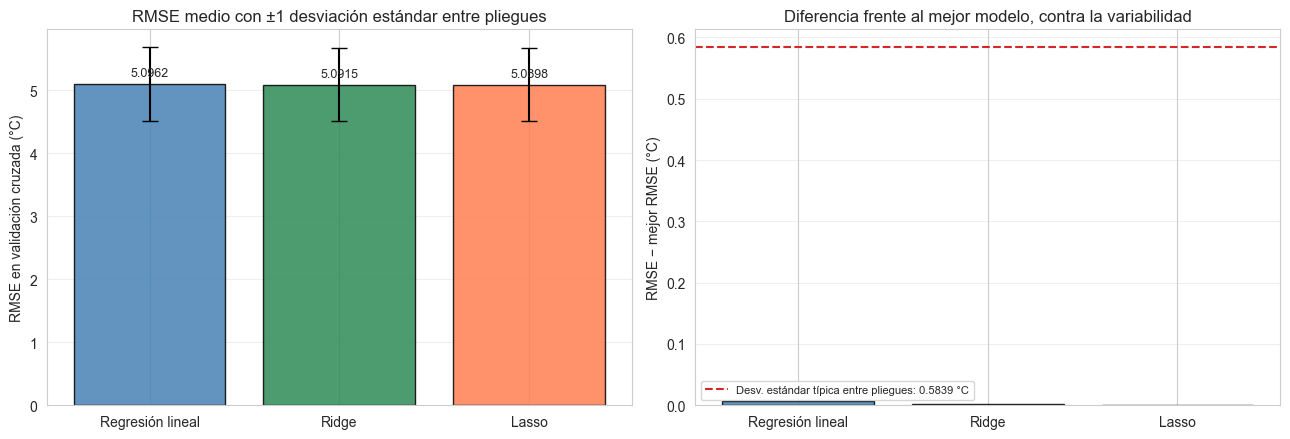

Rango de RMSE entre los tres modelos: 0.0064 °C
Desviación estándar típica entre pliegues: 0.5839 °C


In [35]:
tabla_regularizacion = pd.DataFrame([resultado_lineal, resultado_ridge, resultado_lasso])
tabla_regularizacion["Brecha (CV - train)"] = (
    tabla_regularizacion["RMSE medio CV"] - tabla_regularizacion["RMSE train"])

coefs_no_nulos = []
for pipe in [mejor_lineal, mejor_ridge, mejor_lasso]:
    tabla_coef, _ = extraer_coeficientes(pipe)
    coefs_no_nulos.append(int((tabla_coef["Magnitud"] > TOL_CERO).sum()))
tabla_regularizacion["Coefs. no nulos"] = coefs_no_nulos

columnas = ["Modelo", "Mejores hiperparámetros", "RMSE medio CV", "Desv. RMSE",
            "MAE medio CV", "R² medio CV", "RMSE train", "Brecha (CV - train)",
            "Coefs. no nulos"]

display(tabla_regularizacion[columnas].style.format({
    "RMSE medio CV": "{:.4f}", "Desv. RMSE": "{:.4f}", "MAE medio CV": "{:.4f}",
    "R² medio CV": "{:.4f}", "RMSE train": "{:.4f}", "Brecha (CV - train)": "{:.4f}",
}).highlight_min(subset=["RMSE medio CV"], color="lightgreen"))

# --- Gráfico: la diferencia entre modelos frente a la variabilidad entre pliegues ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

modelos_reg = tabla_regularizacion["Modelo"]
rmse_vals = tabla_regularizacion["RMSE medio CV"]
rmse_desv = tabla_regularizacion["Desv. RMSE"]

barras = axes[0].bar(modelos_reg, rmse_vals, yerr=rmse_desv, capsize=6,
                     color=["steelblue", "seagreen", "coral"], edgecolor="k", alpha=0.85)
axes[0].set_ylabel("RMSE en validación cruzada (°C)")
axes[0].set_title("RMSE medio con ±1 desviación estándar entre pliegues")
axes[0].grid(axis="y", alpha=0.3)
for barra, valor in zip(barras, rmse_vals):
    axes[0].text(barra.get_x() + barra.get_width() / 2, barra.get_height() + 0.08,
                 f"{valor:.4f}", ha="center", va="bottom", fontsize=9)

# Zoom: la escala de las diferencias reales entre los tres modelos
base = rmse_vals.min()
axes[1].bar(modelos_reg, rmse_vals - base,
            color=["steelblue", "seagreen", "coral"], edgecolor="k", alpha=0.85)
axes[1].axhline(rmse_desv.mean(), color="tab:red", ls="--",
                label=f"Desv. estándar típica entre pliegues: {rmse_desv.mean():.4f} °C")
axes[1].set_ylabel("RMSE − mejor RMSE (°C)")
axes[1].set_title("Diferencia frente al mejor modelo, contra la variabilidad")
axes[1].legend(fontsize=8)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Rango de RMSE entre los tres modelos: {rmse_vals.max() - rmse_vals.min():.4f} °C")
print(f"Desviación estándar típica entre pliegues: {rmse_desv.mean():.4f} °C")

In [36]:
tabla_lasso_optimo, _ = extraer_coeficientes(mejor_lasso)

variables_anuladas_optimo = tabla_lasso_optimo.loc[
    tabla_lasso_optimo["Coeficiente"].abs() <= TOL_CERO,
    "Característica"
].tolist()

print(f"Características totales: {len(tabla_lasso_optimo)}")
print(
    "Coeficientes no nulos:",
    int((tabla_lasso_optimo["Coeficiente"].abs() > TOL_CERO).sum())
)
print(f"Variables anuladas por el mejor Lasso: {variables_anuladas_optimo}")

Características totales: 33
Coeficientes no nulos: 30
Variables anuladas por el mejor Lasso: ['rafaga_rango', 'registros_del_dia', 'presion_rango']


### 4.5 Comparación entre regresión lineal, Ridge y Lasso

Lasso obtiene el menor RMSE promedio en validación cruzada (**5.0898 °C**), seguido por Ridge (**5.0915 °C**) y la regresión lineal (**5.0962 °C**).

Sin embargo, la diferencia máxima entre los tres modelos es únicamente de **0.0064 °C**, mientras que la desviación estándar típica entre los pliegues es aproximadamente **0.5839 °C**. La variabilidad propia de la validación cruzada es, por tanto, mucho mayor que las diferencias de desempeño promedio entre los modelos.

En consecuencia, no existe evidencia suficiente para afirmar que alguno de los tres modelos tenga una ventaja predictiva sustancial sobre los demás. La regularización produce pequeños cambios en el error promedio y en la magnitud de los coeficientes, pero no genera una mejora relevante de generalización sobre la representación lineal.

La principal diferencia aparece en términos de complejidad e interpretabilidad. Ridge conserva todas las características y contrae sus coeficientes, mientras que el mejor modelo Lasso produce una representación más dispersa, conservando **30 de los 33 coeficientes**. Esta capacidad de llevar coeficientes exactamente a cero permite utilizar Lasso como mecanismo de selección automática de características.

El mejor modelo Lasso, obtenido con `alpha = 0.00316228` y `MinMaxScaler`, conserva **30 de las 33 características** y lleva exactamente a cero los coeficientes asociados con `rafaga_rango`, `registros_del_dia` y `presion_rango`.

Esto muestra el efecto característico de la penalización L1: además de contraer los coeficientes, puede eliminar automáticamente algunas características del modelo. En este caso, sin embargo, la reducción de dimensionalidad es moderada, ya que solo se eliminan 3 de las 33 características transformadas.

Estas variables no deben interpretarse como irrelevantes en términos absolutos. El resultado indica únicamente que, dada la información proporcionada por las demás variables y el nivel de penalización seleccionado mediante validación cruzada, Lasso puede prescindir de ellas sin deteriorar su desempeño predictivo.

### 4.6 Lectura de la comparación

**Los tres modelos son indistinguibles en desempeño.** El RMSE en validación cruzada va de 5.331 °C
(Ridge) a 5.337 °C (lineal), un rango de unas seis milésimas de grado, frente a una desviación estándar
entre pliegues de 0.58 °C. La diferencia entre los modelos es unas cien veces menor que la variabilidad
de la propia estimación, así que no hay base para afirmar que uno generalice mejor que otro: el panel
derecho de la figura contrasta precisamente esas dos escalas. MAE y R² ordenan los modelos igual y con
la misma magnitud de diferencia, de modo que la conclusión no depende de la métrica.

**Por qué la regularización no aporta aquí, y eso es un resultado, no un fracaso.** La regularización
compra reducción de varianza a cambio de sesgo, y solo es rentable cuando hay varianza que reducir. En
esta representación hay 33 coeficientes para 1 860 observaciones de entrenamiento, unas 56
observaciones por parámetro, y la brecha entre el error de entrenamiento (5.26 °C) y el de validación
(5.34 °C) es de apenas 0.08 °C. Un modelo que generaliza casi tan bien como se ajusta no está
sobreajustando, y por tanto no tiene nada que ganar con una penalización. Es el contraste exacto de la
sección 3: el modelo polinomial de grado 2, con 153 parámetros, sí tenía una brecha enorme, y es ahí
donde la regularización tiene algo que hacer. La sección 5 lo comprueba directamente.

Que los valores óptimos de `alpha` sean pequeños (1 para Ridge, 0.001 para Lasso) confirma lo mismo desde
otro ángulo: la validación cruzada está pidiendo *casi nada* de penalización, es decir, está
recomendando quedarse muy cerca del modelo sin regularizar. Y las rutas de regularización muestran que
cuando se insiste en penalizar, el error empeora de forma monótona: Ridge pasa de 5.34 a 7.28 °C al
llegar a `alpha` = 1 000, y Lasso llega a 9.34 °C —exactamente el RMSE del modelo nulo— porque anula
todos los coeficientes y se queda solo con el intercepto. Ese es el régimen de subajuste por
penalización excesiva, el espejo del sobreajuste de la sección 3.

**Efecto sobre la magnitud de los coeficientes.** Sobre la representación común con `StandardScaler`, la
norma L2 de los coeficientes baja de 24.52 en el modelo sin penalizar a 23.99 con Ridge y 24.28 con
Lasso: una contracción de apenas un 2 %, coherente con lo pequeño de los `alpha` elegidos. El encogimiento
no es uniforme, y en eso sí se ve el mecanismo: los coeficientes que más se reducen son los de las
indicadoras de `sector_viento` (por ejemplo `sector_viento_NO` pasa de −4.32 a −3.93), que son las
estimaciones más inciertas porque se apoyan en pocas observaciones por categoría, mientras que
coeficientes bien determinados como `viento_norte` (−1.631) quedan prácticamente intactos. La
penalización actúa preferentemente donde la evidencia es débil, que es justamente lo que se espera de
ella.

Las rutas de regularización hacen visible la diferencia estructural entre las dos penalizaciones, que en
el óptimo queda oculta. En **Ridge** los 33 coeficientes se contraen de forma continua hacia cero pero
ninguno llega a anularse en todo el rango explorado: el modelo conserva siempre las 33 variables. En
**Lasso** el número de coeficientes no nulos cae por escalones —33, 30, 28, 21, 14, 3, 1 y finalmente
0— a medida que `alpha` crece. Esa es la selección automática de características: L1 no encoge, elimina.

**Qué elimina Lasso y qué significa.** En su óptimo (`alpha` = 0.001 con `StandardScaler`) Lasso no
anula ninguna variable, y con el escalador que gana globalmente anula solo dos: `presion_rango` y
`humedad_rango`, precisamente las dos de coeficiente más pequeño en el modelo sin penalizar (0.033 y
−0.007 °C por unidad estandarizada). La lectura honesta es que **en este conjunto de variables no hay
redundancia relevante que eliminar**: la ingeniería de características del Laboratorio 1 ya había
sustituido los pares mínimo/máximo por rangos y descartado las variables duplicadas, así que Lasso llega
a un conjunto sobre el que queda poco por podar.

Aun así, la tabla de parsimonia muestra que existe un compromiso aprovechable. Con `alpha` = 0.0316
Lasso conserva 28 de las 33 características a un costo de 0.023 °C de RMSE, y con `alpha` = 0.1 conserva
21 características por 0.174 °C. Para AlpesPlanck esa es una decisión de ingeniería más que de
estadística: si mantener un sensor o una variable derivada tiene costo operativo, sacrificar dos
centésimas de grado por prescindir de cinco variables puede ser un buen negocio, y la tabla cuantifica
el precio exacto de cada nivel de simplificación.

**Sobre la elección del escalador.** Ridge y Lasso eligen `MinMaxScaler` y el modelo lineal
`RobustScaler`, pero las diferencias son de milésimas de grado y caen dentro del ruido, así que la
elección del escalador no está realmente determinada por los datos. Conviene no leerla como un hallazgo.
Lo que sí importa —y se verificó explícitamente en 4.1— es que sin penalización el escalador no cambia
nada, mientras que con penalización sí interactúa con `alpha`: el `alpha` óptimo depende del escalador,
porque ambas cosas actúan sobre la misma magnitud. Esa es la razón de fondo por la que el análisis de
coeficientes de 4.4 tuvo que fijar el escalador antes de comparar magnitudes.

**Qué se lleva la sección 5.** Como Ridge y Lasso son equivalentes en desempeño sobre esta
representación, la evidencia de esta sección no basta por sí sola para escoger entre L1 y L2 para el
modelo polinomial regularizado; la decisión debe argumentarse con el criterio que resulte pertinente
allí (número de términos de interacción, interpretabilidad o costo de la búsqueda) y verificarse con
validación cruzada.

## 5. Actividad 4. Regresión polinomial regularizada

En esta actividad se combinarán los dos mecanismos de control de complejidad estudiados anteriormente:

- La generación de características polinomiales.
- La regularización de los coeficientes.

Se construirá un pipeline que combine `PolynomialFeatures` con un estimador regularizado, utilizando Ridge o Lasso según la evidencia obtenida en la sección anterior.

La búsqueda mediante `GridSearchCV` explorará simultáneamente:

- El grado del polinomio.
- El parámetro de penalización.
- La estrategia de escalamiento.

El modelo será evaluado mediante RMSE, MAE y R² utilizando el mismo esquema de validación cruzada empleado en las demás actividades.

El análisis se concentrará en determinar si la regularización permite controlar el sobreajuste cuando aumenta la complejidad del modelo.

No se asumirá previamente que el modelo regularizado permitirá utilizar un grado mayor. Esta conclusión se establecerá únicamente a partir de los resultados obtenidos.

In [43]:
# ============================================================
# 5. Regresión polinomial regularizada con Ridge
# ============================================================

transformador_numerico_poly_reg = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("polynomial", PolynomialFeatures(include_bias=False)),
])

preprocesador_poly_reg = ColumnTransformer(transformers=[
    ("num", transformador_numerico_poly_reg, variables_numericas),
    ("cat", transformador_categorico, variables_categoricas),
])

pipeline_poly_reg = Pipeline(steps=[
    ("preprocesamiento", preprocesador_poly_reg),
    ("modelo", Ridge()),
])

# Rejilla reducida pero cubriendo grado, escalamiento y regularización
param_grid_poly_reg = {
    "preprocesamiento__num__polynomial__degree": [1, 2, 3],
    "preprocesamiento__num__scaler": [
        StandardScaler(),
        MinMaxScaler(),
        RobustScaler(),
    ],
    "modelo__alpha": [0.1, 1, 10, 100],
}

n_combinaciones_poly_reg = (
    3 * 3 * 4
)

print(f"Combinaciones: {n_combinaciones_poly_reg}")
print(
    f"Ajustes totales: {n_combinaciones_poly_reg} × "
    f"{kfold.n_splits} = "
    f"{n_combinaciones_poly_reg * kfold.n_splits}"
)

Combinaciones: 36
Ajustes totales: 36 × 10 = 360


In [45]:
grid_poly_reg = GridSearchCV(
    estimator=pipeline_poly_reg,
    param_grid=param_grid_poly_reg,
    cv=kfold,
    scoring=scoring,
    refit=REFIT_METRIC,
    return_train_score=True,
    n_jobs=-1,
)

grid_poly_reg.fit(X_train, y_train)

mejor_poly_reg = grid_poly_reg.best_estimator_

resultado_poly_reg = extraer_resultados(
    grid_poly_reg,
    "Polinomial + Ridge"
)

print("Mejores hiperparámetros:")
print(formatear_params(grid_poly_reg.best_params_))

print(
    f"\nRMSE CV: {resultado_poly_reg['RMSE medio CV']:.4f} "
    f"± {resultado_poly_reg['Desv. RMSE']:.4f} °C"
)

print(f"MAE CV:       {resultado_poly_reg['MAE medio CV']:.4f} °C")
print(f"R² CV:        {resultado_poly_reg['R² medio CV']:.4f}")
print(f"RMSE train:   {resultado_poly_reg['RMSE train']:.4f} °C")

Mejores hiperparámetros:
alpha=1, degree=3, scaler=MinMaxScaler

RMSE CV: 5.0087 ± 0.5379 °C
MAE CV:       3.6770 °C
R² CV:        0.6995
RMSE train:   4.7185 °C


Se utiliza Ridge como estimador regularizado. En la sección anterior, Ridge y Lasso presentaron desempeños prácticamente equivalentes en validación cruzada, mientras que Ridge mostró una variabilidad ligeramente menor entre pliegues. En esta actividad el objetivo principal es analizar si la penalización puede controlar el aumento de varianza producido por la expansión polinomial, por lo que se utiliza la penalización L2.

### 5.1 Interpretación de la regresión polinomial regularizada

La búsqueda conjunta sobre grado del polinomio, intensidad de regularización y estrategia de escalamiento seleccionó como mejor configuración un modelo **Ridge de grado 3**, con `alpha = 1` y `MinMaxScaler`.

El modelo obtiene un RMSE promedio de **5.0087 °C**, un MAE de **3.6770 °C** y un R² de **0.6995** en validación cruzada. La desviación estándar del RMSE es de **0.5379 °C** y el RMSE de entrenamiento es **4.7185 °C**, produciendo una brecha entrenamiento-validación de aproximadamente **0.2902 °C**.

Este resultado contrasta fuertemente con la regresión polinomial sin regularización. En esa actividad, los modelos de grados superiores presentaban errores de validación muy altos a pesar de reducir progresivamente el error de entrenamiento, evidenciando sobreajuste e inestabilidad.

Al introducir la penalización L2, un polinomio de **grado 3** puede utilizarse sin que el error de validación aumente de forma extrema. Ridge reduce la sensibilidad del modelo a la gran cantidad de términos generados por la expansión polinomial mediante la contracción de sus coeficientes.

Además, el modelo polinomial regularizado mejora el RMSE promedio frente al mejor modelo lineal sin regularización (**5.0962 °C**), Ridge lineal (**5.0915 °C**) y Lasso lineal (**5.0898 °C**).

Sin embargo, la diferencia de desempeño sigue siendo pequeña frente a la variabilidad entre los pliegues de validación cruzada. Por lo tanto, la selección final no debe basarse únicamente en el menor RMSE promedio, sino también en la estabilidad y complejidad de cada alternativa.

En conclusión, en este conjunto de datos la regularización sí permite controlar gran parte del sobreajuste provocado por la expansión polinomial y recuperar un modelo de mayor complejidad con buen desempeño de generalización.

## 6. Actividad 5. Comparación y selección del mejor modelo

En esta sección se consolidan los resultados obtenidos mediante validación cruzada para todos los modelos construidos anteriormente.

La comparación se realiza considerando tres criterios:

1. **Desempeño promedio**, principalmente a partir del RMSE y complementado con MAE y R².
2. **Estabilidad**, medida mediante la desviación estándar de las métricas entre los pliegues de validación cruzada.
3. **Complejidad del modelo**, considerando el tipo de representación, el grado polinomial y la regularización utilizada.

La tabla comparativa se genera directamente a partir de los resultados almacenados de cada búsqueda, evitando transcribir manualmente las métricas.

La selección del modelo final se realiza exclusivamente con la información obtenida sobre el conjunto de entrenamiento mediante validación cruzada y **antes de utilizar el conjunto de test**.

In [46]:
# ============================================================
# 6. Comparación general de modelos
# ============================================================

tabla_comparacion = pd.DataFrame([
    resultado_lineal,
    resultado_poly,
    resultado_ridge,
    resultado_lasso,
    resultado_poly_reg,
])

tabla_comparacion["Complejidad"] = [
    "Lineal",
    "Polinomial grado 1",
    "Lineal + L2",
    "Lineal + L1",
    "Polinomial grado 3 + L2",
]

tabla_comparacion = (
    tabla_comparacion
    .sort_values("RMSE medio CV")
    .reset_index(drop=True)
)

display(
    tabla_comparacion.style.format({
        "RMSE medio CV": "{:.4f}",
        "Desv. RMSE": "{:.4f}",
        "MAE medio CV": "{:.4f}",
        "Desv. MAE": "{:.4f}",
        "R² medio CV": "{:.4f}",
        "Desv. R²": "{:.4f}",
        "RMSE train": "{:.4f}",
    })
)

,Modelo,Mejores hiperparámetros,RMSE medio CV,Desv. RMSE,MAE medio CV,Desv. MAE,R² medio CV,Desv. R²,RMSE train,Complejidad
0,Polinomial + Ridge,"alpha=1, degree=3, scaler=MinMaxScaler",5.0087,0.5379,3.6770,0.2426,0.6995,0.0569,4.7185,Polinomial grado 3 + L2
1,Lasso,"alpha=0.00316228, scaler=MinMaxScaler",5.0898,0.5835,3.7633,0.3303,0.6892,0.0642,5.0219,Lineal + L1
2,Ridge,"alpha=1, scaler=MinMaxScaler",5.0915,0.5812,3.7680,0.3284,0.6890,0.0639,5.0201,Lineal + L2
3,Regresión lineal,scaler=RobustScaler,5.0962,0.5869,3.7713,0.3301,0.6884,0.0647,5.0175,Lineal
4,Regresión polinomial,"degree=1, scaler=RobustScaler",5.0962,0.5869,3.7713,0.3301,0.6884,0.0647,5.0175,Polinomial grado 1


In [47]:
modelo_seleccionado = mejor_poly_reg

print("Modelo seleccionado: Polinomial + Ridge")
print("Hiperparámetros:")
print(formatear_params(grid_poly_reg.best_params_))

Modelo seleccionado: Polinomial + Ridge
Hiperparámetros:
alpha=1, degree=3, scaler=MinMaxScaler


### 6.1 Argumentación de la selección

El modelo seleccionado es **Polinomial + Ridge**, con `degree = 3`, `alpha = 1` y `MinMaxScaler`.

Este modelo obtiene el menor RMSE promedio en validación cruzada (**5.0087 °C**) y también la menor desviación estándar del RMSE (**0.5379 °C**) entre los modelos comparados. Además, presenta el menor MAE (**3.6770 °C**) y el mayor R² (**0.6995**).

Aunque es más complejo que los modelos lineales, la regularización Ridge permite controlar el sobreajuste observado previamente en la regresión polinomial sin regularización. La diferencia entre el RMSE de entrenamiento (**4.7185 °C**) y el de validación (**5.0087 °C**) es de aproximadamente **0.2902 °C**, por lo que no se observa la inestabilidad extrema encontrada anteriormente en los modelos polinomiales de grados altos.

Por estas razones, se selecciona **Polinomial + Ridge** como modelo final antes de evaluar cualquier resultado sobre el conjunto de test.

## 7. Evaluación final e intervalos de confianza

Una vez terminada la selección de modelos y congeladas todas las decisiones de modelado, se utilizará el conjunto de test.

El conjunto de test no se utilizará para modificar grados, parámetros de regularización, estrategias de escalamiento ni ninguna otra decisión tomada anteriormente.

### 7.1 Evaluación final sobre el conjunto de test

Una vez finalizada la selección del modelo mediante validación cruzada, se evalúan los modelos construidos sobre el conjunto de test reservado desde el inicio del laboratorio.

Los hiperparámetros y la selección del modelo ya se encuentran congelados. Por lo tanto, los resultados obtenidos sobre test se utilizarán únicamente para estimar la capacidad de generalización final y **no para modificar ninguna decisión de modelado**.

Para cada modelo se calcularán:

- RMSE.
- MAE.
- R².

También se comparará el orden de desempeño observado en test con el obtenido previamente mediante validación cruzada.

In [48]:
# ============================================================
# 7.1 Evaluación final sobre el conjunto de test
# ============================================================

# Los best_estimator_ de GridSearchCV ya quedaron ajustados
# nuevamente sobre todo X_train debido a refit.

modelos_finales = {
    "Regresión lineal": mejor_lineal,
    "Regresión polinomial": mejor_poly,
    "Ridge": mejor_ridge,
    "Lasso": mejor_lasso,
    "Polinomial + Ridge": mejor_poly_reg,
}

resultados_test = []

for nombre, modelo in modelos_finales.items():
    
    y_pred = modelo.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    resultados_test.append({
        "Modelo": nombre,
        "RMSE test": rmse,
        "MAE test": mae,
        "R² test": r2,
    })


tabla_test = (
    pd.DataFrame(resultados_test)
    .sort_values("RMSE test")
    .reset_index(drop=True)
)

display(
    tabla_test.style.format({
        "RMSE test": "{:.4f}",
        "MAE test": "{:.4f}",
        "R² test": "{:.4f}",
    })
)

,Modelo,RMSE test,MAE test,R² test
0,Polinomial + Ridge,5.0008,3.5829,0.6954
1,Lasso,5.0064,3.6624,0.6947
2,Ridge,5.0085,3.6636,0.6944
3,Regresión lineal,5.0137,3.6630,0.6938
4,Regresión polinomial,5.0137,3.6630,0.6938


### Interpretación de la evaluación sobre test

El modelo **Polinomial + Ridge**, seleccionado previamente mediante validación cruzada, también obtiene el mejor desempeño sobre el conjunto de test. Presenta un RMSE de **5.0008 °C**, un MAE de **3.5829 °C** y un R² de **0.6954**.

Este resultado es consistente con la selección realizada anteriormente, donde el mismo modelo obtuvo el menor RMSE promedio y la menor desviación estándar en validación cruzada.

Además, el RMSE obtenido en test (**5.0008 °C**) es muy cercano al RMSE promedio observado durante validación cruzada (**5.0087 °C**). Esta similitud sugiere que la estimación obtenida durante el proceso de validación representó adecuadamente el desempeño posterior sobre datos no utilizados durante la selección del modelo.

Sin embargo, las diferencias entre los modelos continúan siendo pequeñas. Por ejemplo, Lasso obtiene un RMSE de **5.0064 °C**, apenas superior al del modelo seleccionado. Por lo tanto, aunque Polinomial + Ridge ocupa el primer lugar tanto en validación cruzada como en test, no debe interpretarse como una superioridad amplia frente a las alternativas lineales regularizadas.

### 7.2 Intervalos de confianza mediante bootstrapping

El procedimiento de bootstrapping se aplicará al modelo seleccionado previamente en la sección 6.

Se utilizará el conjunto de test y se realizarán al menos 500 remuestreos con reemplazo.

En cada remuestreo se calcularán nuevamente las métricas de desempeño utilizando las observaciones reales y sus predicciones correspondientes.

Se estimarán intervalos de confianza del 95 % para:

- RMSE.
- MAE.
- R².

Los intervalos se obtendrán utilizando los percentiles 2.5 y 97.5 de las distribuciones generadas mediante bootstrap.

También se visualizarán las distribuciones de las métricas remuestreadas y de los errores de predicción.

El objetivo de esta etapa es cuantificar la incertidumbre asociada al desempeño del modelo y analizar su estabilidad.

In [49]:
# ============================================================
# 7.2 Bootstrap del modelo seleccionado
# ============================================================

N_BOOTSTRAP = 1000

# Predicciones finales del modelo seleccionado
y_pred_seleccionado = modelo_seleccionado.predict(X_test)

# Generador reproducible
rng = np.random.default_rng(RANDOM_STATE)

rmse_boot = []
mae_boot = []
r2_boot = []

n_test = len(y_test)

for _ in range(N_BOOTSTRAP):

    # Remuestreo con reemplazo de los índices del conjunto de test
    indices = rng.choice(
        n_test,
        size=n_test,
        replace=True
    )

    y_real_boot = np.asarray(y_test)[indices]
    y_pred_boot = np.asarray(y_pred_seleccionado)[indices]

    rmse_boot.append(
        np.sqrt(mean_squared_error(y_real_boot, y_pred_boot))
    )

    mae_boot.append(
        mean_absolute_error(y_real_boot, y_pred_boot)
    )

    r2_boot.append(
        r2_score(y_real_boot, y_pred_boot)
    )


rmse_boot = np.array(rmse_boot)
mae_boot = np.array(mae_boot)
r2_boot = np.array(r2_boot)


# ============================================================
# Intervalos de confianza del 95 %
# ============================================================

def intervalo_95(valores):
    return np.percentile(valores, [2.5, 97.5])


ic_rmse = intervalo_95(rmse_boot)
ic_mae = intervalo_95(mae_boot)
ic_r2 = intervalo_95(r2_boot)


print(f"Bootstrap realizado: {N_BOOTSTRAP} remuestreos")

print(
    f"\nRMSE test: {np.sqrt(mean_squared_error(y_test, y_pred_seleccionado)):.4f} °C"
)
print(
    f"IC 95% RMSE: [{ic_rmse[0]:.4f}, {ic_rmse[1]:.4f}] °C"
)

print(
    f"\nMAE test: {mean_absolute_error(y_test, y_pred_seleccionado):.4f} °C"
)
print(
    f"IC 95% MAE: [{ic_mae[0]:.4f}, {ic_mae[1]:.4f}] °C"
)

print(
    f"\nR² test: {r2_score(y_test, y_pred_seleccionado):.4f}"
)
print(
    f"IC 95% R²: [{ic_r2[0]:.4f}, {ic_r2[1]:.4f}]"
)

Bootstrap realizado: 1000 remuestreos

RMSE test: 5.0008 °C
IC 95% RMSE: [4.2414, 6.0830] °C

MAE test: 3.5829 °C
IC 95% MAE: [3.3220, 3.8818] °C

R² test: 0.6954
IC 95% R²: [0.5903, 0.7701]


### Interpretación de los intervalos de confianza

Se realizaron **1000 remuestreos bootstrap** sobre el conjunto de test para cuantificar la incertidumbre asociada al desempeño del modelo seleccionado.

El RMSE puntual es de **5.0008 °C**, con un intervalo de confianza del 95 % entre **4.2414 °C y 6.0830 °C**. Este intervalo muestra que existe cierta variabilidad en el error cuadrático dependiendo de las observaciones incluidas en cada remuestreo.

El MAE presenta un valor puntual de **3.5829 °C** y un intervalo de confianza del 95 % entre **3.3220 °C y 3.8818 °C**. Este intervalo es proporcionalmente más estrecho que el del RMSE, lo que es consistente con que el RMSE sea más sensible a errores de gran magnitud.

Para R² se obtiene un valor puntual de **0.6954**, con un intervalo de confianza entre **0.5903 y 0.7701**. Por tanto, según los remuestreos realizados, el modelo explica aproximadamente entre el 59 % y el 77 % de la variabilidad observada en la variable objetivo.

En conjunto, los resultados muestran que el modelo mantiene un desempeño razonablemente estable, aunque la amplitud del intervalo del RMSE sugiere que algunas observaciones con errores grandes pueden afectar de manera importante esta métrica.

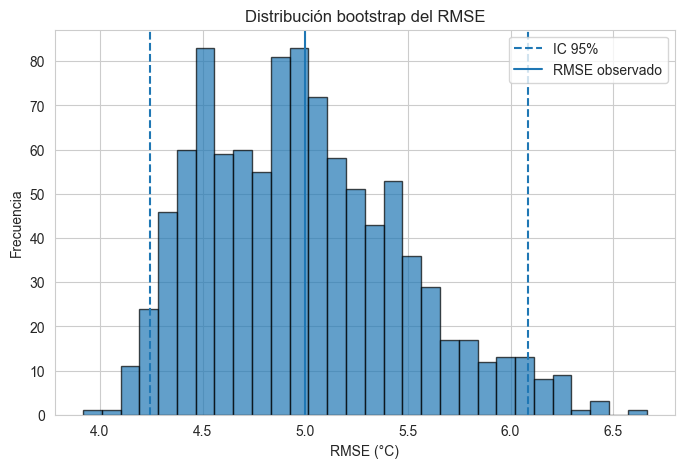

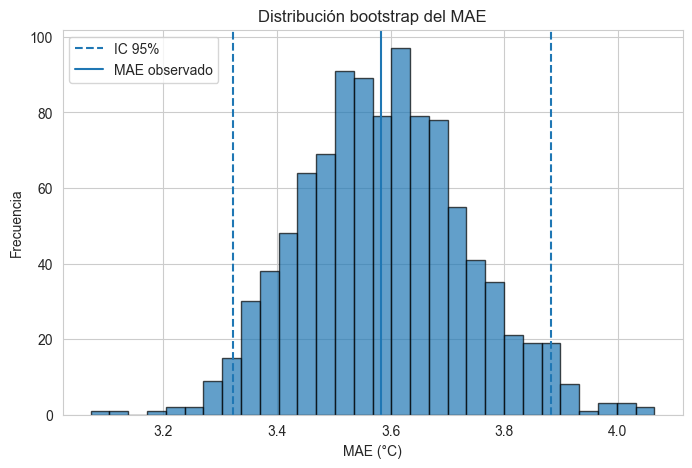

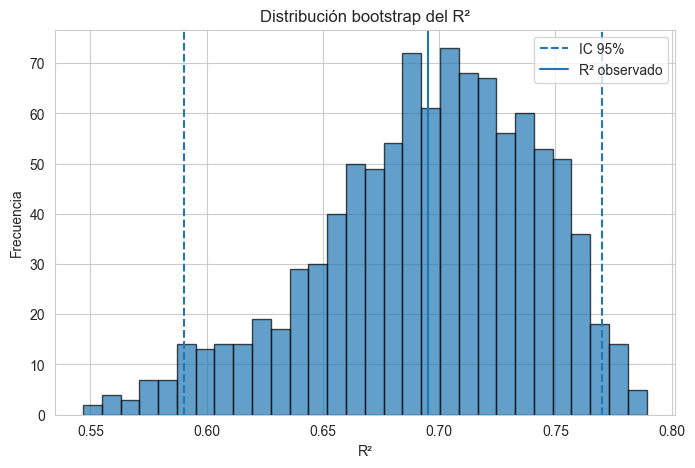

In [50]:
# ============================================================
# Distribuciones bootstrap
# ============================================================

plt.figure(figsize=(8, 5))
plt.hist(rmse_boot, bins=30, edgecolor="black", alpha=0.7)
plt.axvline(ic_rmse[0], linestyle="--", label="IC 95%")
plt.axvline(ic_rmse[1], linestyle="--")
plt.axvline(
    np.sqrt(mean_squared_error(y_test, y_pred_seleccionado)),
    linestyle="-",
    label="RMSE observado"
)
plt.xlabel("RMSE (°C)")
plt.ylabel("Frecuencia")
plt.title("Distribución bootstrap del RMSE")
plt.legend()
plt.show()


plt.figure(figsize=(8, 5))
plt.hist(mae_boot, bins=30, edgecolor="black", alpha=0.7)
plt.axvline(ic_mae[0], linestyle="--", label="IC 95%")
plt.axvline(ic_mae[1], linestyle="--")
plt.axvline(
    mean_absolute_error(y_test, y_pred_seleccionado),
    linestyle="-",
    label="MAE observado"
)
plt.xlabel("MAE (°C)")
plt.ylabel("Frecuencia")
plt.title("Distribución bootstrap del MAE")
plt.legend()
plt.show()


plt.figure(figsize=(8, 5))
plt.hist(r2_boot, bins=30, edgecolor="black", alpha=0.7)
plt.axvline(ic_r2[0], linestyle="--", label="IC 95%")
plt.axvline(ic_r2[1], linestyle="--")
plt.axvline(
    r2_score(y_test, y_pred_seleccionado),
    linestyle="-",
    label="R² observado"
)
plt.xlabel("R²")
plt.ylabel("Frecuencia")
plt.title("Distribución bootstrap del R²")
plt.legend()
plt.show()

Media de los residuales: 0.0272 °C
Mediana de los residuales: -0.2342 °C
RMSE / MAE: 1.3958


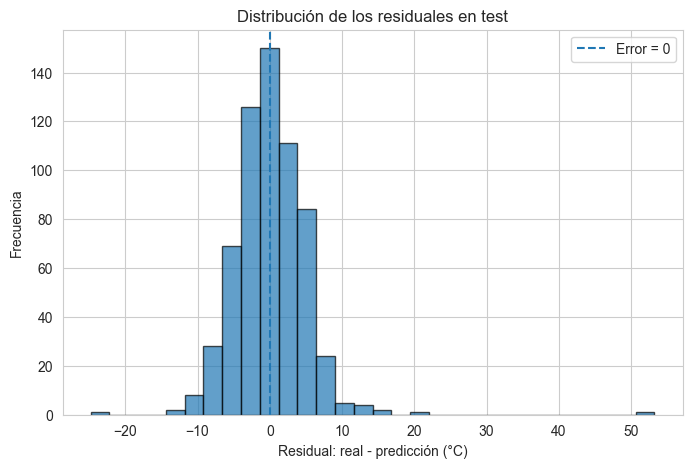

In [52]:
# ============================================================
# Distribución de residuales
# ============================================================

residuales = np.asarray(y_test) - np.asarray(y_pred_seleccionado)

rmse_final = np.sqrt(
    mean_squared_error(y_test, y_pred_seleccionado)
)

mae_final = mean_absolute_error(
    y_test, y_pred_seleccionado
)

cociente_rmse_mae = rmse_final / mae_final

print(f"Media de los residuales: {residuales.mean():.4f} °C")
print(f"Mediana de los residuales: {np.median(residuales):.4f} °C")
print(f"RMSE / MAE: {cociente_rmse_mae:.4f}")


plt.figure(figsize=(8, 5))
plt.hist(residuales, bins=30, edgecolor="black", alpha=0.7)
plt.axvline(0, linestyle="--", label="Error = 0")
plt.xlabel("Residual: real - predicción (°C)")
plt.ylabel("Frecuencia")
plt.title("Distribución de los residuales en test")
plt.legend()
plt.show()

## 8. Análisis de resultados

Las siguientes preguntas se responderán utilizando exclusivamente la evidencia obtenida en las secciones anteriores.

Cada respuesta deberá apoyarse en las métricas, tablas o gráficas producidas durante el laboratorio.

### 8.1 Análisis cuantitativo

#### a. ¿Cuál modelo obtuvo el mejor desempeño en el conjunto de test?

**Respuesta:**

El modelo con mejor desempeño en test fue **Polinomial + Ridge**, con `degree = 3`, `alpha = 1` y `MinMaxScaler`.

Obtuvo:

- RMSE = **5.0008 °C**
- MAE = **3.5829 °C**
- R² = **0.6954**

Fue el modelo con menor RMSE y MAE y con mayor R² entre las alternativas evaluadas. Sin embargo, las diferencias frente a los demás modelos fueron pequeñas; por ejemplo, Lasso obtuvo un RMSE de **5.0064 °C**.

---

#### b. ¿Coincide el mejor desempeño en test con el mejor promedio en validación cruzada? Si no coincide, ¿cuál puede ser la explicación?

**Respuesta:**

Sí. El modelo **Polinomial + Ridge** fue el mejor tanto en validación cruzada como en el conjunto de test.

En validación cruzada obtuvo un RMSE promedio de **5.0087 °C**, mientras que en test obtuvo **5.0008 °C**. La diferencia entre ambos valores es de aproximadamente **0.0079 °C**, por lo que el desempeño observado sobre test es muy cercano al estimado durante la validación cruzada.

Esto indica que, en este caso, el procedimiento de validación permitió obtener una estimación representativa de la capacidad de generalización del modelo.

---

#### c. ¿El modelo con mejor métrica promedio es necesariamente el más adecuado?

**Respuesta:**

No necesariamente. La elección de un modelo no debería depender únicamente del menor error promedio, sino también de su **estabilidad y complejidad**.

Por ejemplo, las diferencias de RMSE entre los modelos lineales fueron muy pequeñas: Lasso obtuvo **5.0898 °C**, Ridge **5.0915 °C** y la regresión lineal **5.0962 °C** en validación cruzada. Estas diferencias son mucho menores que las desviaciones estándar entre pliegues, cercanas a **0.58 °C**.

En este laboratorio, el modelo Polinomial + Ridge sí resulta una elección consistente porque, además de obtener el menor RMSE promedio (**5.0087 °C**), también presenta la menor desviación estándar (**0.5379 °C**). Por lo tanto, combina un mejor promedio con una mayor estabilidad relativa.

---

#### d. Con base en las curvas de validación, ¿cómo cambia el error a medida que aumenta la complejidad? ¿En qué punto se evidencia sobreajuste?

**Respuesta:**

En la regresión polinomial sin regularización, el error de entrenamiento disminuye al aumentar el grado:

- Grado 1: **5.0175 °C**
- Grado 2: **4.6358 °C**
- Grado 3: **3.3867 °C**
- Grado 4: **2.2883 °C**

Sin embargo, utilizando `StandardScaler`, el RMSE de validación pasa de **5.0962 °C** en grado 1 a **9.6030 °C** en grado 2, y posteriormente alcanza valores superiores a **100 °C** en los grados 3 y 4.

Por lo tanto, el sobreajuste comienza a evidenciarse desde el **grado 2**: el modelo mejora su ajuste sobre entrenamiento, pero empeora claramente sobre datos de validación. En los grados 3 y 4 la inestabilidad se vuelve extrema.

---

#### e. ¿Cómo afecta la regularización la magnitud y estabilidad de los coeficientes?

**Respuesta:**

La regularización reduce la magnitud de los coeficientes y limita la sensibilidad del modelo a las variables de entrada.

Utilizando una representación común con `StandardScaler`, la norma L2 de los coeficientes disminuye de **23.4571** en la regresión lineal a **22.9277** con Ridge. Ridge mantiene los 33 coeficientes activos, pero reduce progresivamente su magnitud al aumentar `alpha`.

Lasso también contrae los coeficientes y, a diferencia de Ridge, puede llevar algunos exactamente a cero. En el mejor modelo Lasso global se conservaron **30 de 33 coeficientes**, eliminándose `rafaga_rango`, `registros_del_dia` y `presion_rango`.

Las rutas de regularización muestran además que, al aumentar `alpha`, Ridge reduce los coeficientes de forma progresiva, mientras que Lasso va eliminando características. Una regularización excesiva aumenta nuevamente el error de validación, mostrando el compromiso entre reducción de complejidad y capacidad predictiva.

---

#### f. ¿Los intervalos de confianza obtenidos mediante bootstrapping sugieren estabilidad o alta variabilidad en el desempeño? ¿Qué implicaciones tiene esto?

**Respuesta:**

Los intervalos obtenidos mediante 1000 remuestreos bootstrap muestran que el desempeño presenta una **incertidumbre moderada**.

Los resultados fueron:

- RMSE: **5.0008 °C**, IC 95 % = **[4.2414, 6.0830] °C**
- MAE: **3.5829 °C**, IC 95 % = **[3.3220, 3.8818] °C**
- R²: **0.6954**, IC 95 % = **[0.5903, 0.7701]**

El intervalo del MAE es relativamente concentrado, mientras que el RMSE presenta un intervalo más amplio. Esto sugiere que algunas observaciones con errores grandes pueden afectar de manera importante el desempeño medido con RMSE.

Por lo tanto, aunque el modelo presenta un comportamiento razonablemente consistente, su desempeño real no debe interpretarse únicamente a partir de la estimación puntual de RMSE = 5.0008 °C. Los intervalos muestran el rango de incertidumbre que debe considerarse al utilizar sus predicciones.

In [53]:
# ============================================================
# Características más relevantes del mejor modelo Lasso
# ============================================================

tabla_lasso_optimo, _ = extraer_coeficientes(mejor_lasso)

print("10 características con mayor magnitud en el mejor Lasso:")
display(
    tabla_lasso_optimo.head(10).style.format({
        "Coeficiente": "{:.4f}",
        "Magnitud": "{:.4f}",
    })
)

print("\nVariables anuladas por Lasso:")
display(
    tabla_lasso_optimo[
        tabla_lasso_optimo["Coeficiente"].abs() <= TOL_CERO
    ][["Característica", "Coeficiente"]]
)

10 características con mayor magnitud en el mejor Lasso:


,Característica,Coeficiente,Magnitud
0,viento_norte,-13.1101,13.1101
1,mes_calendario_enero,-9.3838,9.3838
2,mes_calendario_julio,9.1232,9.1232
3,mes_calendario_febrero,-9.0688,9.0688
4,mes_calendario_agosto,8.3784,8.3784
5,humedad_desv,7.0416,7.0416
6,mes_calendario_junio,6.7064,6.7064
7,mes_calendario_diciembre,-6.0789,6.0789
8,humedad_media,-5.5826,5.5826
9,mes_calendario_marzo,-4.5928,4.5928



Variables anuladas por Lasso:


,Característica,Coeficiente
30,rafaga_rango,0.0
31,registros_del_dia,0.0
32,presion_rango,-0.0


### 8.2 Análisis cualitativo

#### a. ¿Qué variables fueron seleccionadas como más relevantes por el modelo Lasso?

**Respuesta:**

En el mejor modelo Lasso, ajustado con `alpha = 0.00316228` y `MinMaxScaler`, las características con coeficientes de mayor magnitud fueron:

- `viento_norte`: **-13.1101**
- `mes_calendario_enero`: **-9.3838**
- `mes_calendario_julio`: **9.1232**
- `mes_calendario_febrero`: **-9.0688**
- `mes_calendario_agosto`: **8.3784**
- `humedad_desv`: **7.0416**
- `mes_calendario_junio`: **6.7064**
- `mes_calendario_diciembre`: **-6.0789**
- `humedad_media`: **-5.5826**
- `mes_calendario_marzo`: **-4.5928**

De acuerdo con la magnitud de los coeficientes dentro de esta representación, `viento_norte` es la característica con mayor peso en el modelo. También se observa una presencia importante de variables asociadas al mes calendario y a la humedad, lo que sugiere que la estacionalidad y las condiciones de humedad contienen información relevante para la estimación de la temperatura máxima.

Los signos indican la dirección de la asociación dentro del modelo: por ejemplo, `viento_norte`, `humedad_media` y algunos meses presentan coeficientes negativos, mientras que meses como julio y agosto y `humedad_desv` presentan coeficientes positivos. Estas relaciones corresponden al modelo ajustado y no deben interpretarse como relaciones causales.

Lasso eliminó completamente tres características:

- `rafaga_rango`
- `registros_del_dia`
- `presion_rango`

Esto muestra su capacidad para realizar selección automática de características mediante la penalización L1. Sin embargo, que una variable tenga coeficiente cero no significa que sea irrelevante en términos absolutos, sino que el modelo puede prescindir de ella dadas las demás variables disponibles.

---

#### b. ¿Qué interpretación práctica tienen los coeficientes del modelo final en el contexto de la estimación de temperatura máxima?

**Respuesta:**

El modelo final es una regresión polinomial de grado 3 regularizada con Ridge. Por esta razón, sus coeficientes no corresponden únicamente a efectos lineales directos de las variables originales: el modelo incluye también potencias y combinaciones entre las características numéricas.

Además, las variables fueron escaladas antes de ingresar al modelo. Por lo tanto, la magnitud de un coeficiente individual no debe interpretarse directamente como el cambio en grados Celsius producido por una unidad de la variable original.

En este modelo, los coeficientes sirven principalmente para construir la predicción conjunta. Su interpretación individual es menos directa que en una regresión lineal simple, especialmente porque la presencia de términos polinomiales hace que el efecto de una característica pueda depender de su propio nivel y de otras características.

---

#### c. ¿Existen diferencias relevantes entre el modelo más preciso y el más interpretable?

**Respuesta:**

Sí. El modelo más preciso fue **Polinomial + Ridge**, con un RMSE de test de **5.0008 °C**, pero también es el modelo de mayor complejidad entre las alternativas seleccionadas, debido a la expansión polinomial de grado 3.

Los modelos lineales son más fáciles de interpretar porque cada característica aparece de forma directa y sus coeficientes pueden relacionarse más fácilmente con la variable objetivo. Lasso agrega además la ventaja de realizar selección automática de características.

Sin embargo, la mejora predictiva del modelo Polinomial + Ridge frente a Lasso fue pequeña: el RMSE de test pasó de **5.0064 °C** a **5.0008 °C**, una diferencia de aproximadamente **0.0056 °C**.

Por lo tanto, si la prioridad fuera únicamente la interpretabilidad, un modelo lineal regularizado podría ser una alternativa razonable. Si se prioriza estrictamente el mejor desempeño predictivo observado, el modelo Polinomial + Ridge conserva la ventaja.

---

#### d. ¿Qué decisiones estratégicas podría tomar AlpesPlanck a partir de los resultados obtenidos?

**Respuesta:**

Los resultados permiten utilizar el modelo como una herramienta de apoyo para estimar la temperatura máxima del día siguiente, teniendo en cuenta que su RMSE de test es aproximadamente **5.0 °C**.

Sin embargo, las decisiones no deberían basarse únicamente en una predicción puntual. El intervalo de confianza bootstrap del RMSE fue **[4.2414, 6.0830] °C**, lo que muestra que existe incertidumbre relevante en el desempeño esperado.

Por lo tanto, AlpesPlanck debería utilizar las predicciones como un insumo adicional dentro de sus procesos de decisión y considerar explícitamente el margen de error del modelo, especialmente en situaciones donde una diferencia de varios grados pueda cambiar una decisión operativa.

---

#### e. ¿Mayor precisión implica necesariamente mayor valor para la organización?

**Respuesta:**

No. Una mejora pequeña en una métrica predictiva no necesariamente genera una mejora relevante para la organización.

En este laboratorio, Polinomial + Ridge obtuvo el mejor RMSE en test (**5.0008 °C**), mientras que Lasso obtuvo **5.0064 °C**. La diferencia es muy pequeña, aunque el modelo polinomial es considerablemente más complejo.

El valor de un modelo también depende de factores como interpretabilidad, estabilidad, facilidad de mantenimiento y utilidad práctica de sus predicciones. Por tanto, una ganancia mínima en precisión puede no justificar un aumento importante de complejidad si no produce una diferencia útil para la organización.

---

#### f. ¿Un modelo más complejo necesariamente genera mayor valor empresarial?

**Respuesta:**

No. Una mayor complejidad puede aumentar la capacidad del modelo para representar relaciones no lineales, pero también puede producir sobreajuste, reducir la interpretabilidad y aumentar el costo de desarrollo y mantenimiento.

Este laboratorio muestra claramente ese comportamiento. Sin regularización, aumentar el grado polinomial produjo un deterioro extremo del desempeño de validación. Solo al incorporar Ridge fue posible utilizar un polinomio de grado 3 de forma estable.

Incluso después de controlar el sobreajuste, la mejora frente a modelos lineales fue pequeña. Por lo tanto, la complejidad adicional solo se justifica cuando produce una mejora suficientemente relevante en desempeño o estabilidad para compensar sus costos y menor interpretabilidad.

### 8.3 Reflexión conceptual

#### a. ¿Qué relación observas entre complejidad del modelo, capacidad de generalización y estabilidad del desempeño?

**Respuesta:**

Los resultados muestran que aumentar la complejidad de un modelo no garantiza una mejor capacidad de generalización.

En la regresión polinomial sin regularización, aumentar el grado redujo progresivamente el error de entrenamiento, pero produjo un fuerte aumento del error de validación. Con `StandardScaler`, el RMSE de validación pasó de **5.0962 °C** en grado 1 a **9.6030 °C** en grado 2 y a valores superiores a **100 °C** en los grados 3 y 4. Al mismo tiempo, aumentó considerablemente la variabilidad entre los pliegues.

Esto evidencia el trade-off entre sesgo y varianza: un modelo más flexible puede ajustarse mejor a los datos de entrenamiento, pero también puede volverse más sensible a las particularidades de la muestra.

La regularización permitió controlar parte de este problema. Al combinar una expansión polinomial de grado 3 con Ridge, el RMSE de validación se redujo hasta **5.0087 °C**, con una desviación estándar de **0.5379 °C** y una brecha entrenamiento-validación de aproximadamente **0.2902 °C**.

Por tanto, la complejidad puede ser útil cuando existe un mecanismo adecuado para controlarla. La mejor generalización no se obtuvo simplemente aumentando el grado, sino combinando mayor capacidad de representación con regularización.

---

#### b. ¿Qué fuentes de sesgo podrían estar presentes en los datos o en el proceso de modelado?

**Respuesta:**

Una posible fuente de sesgo proviene de la propia muestra utilizada para entrenar el modelo. Los datos disponibles representan determinadas condiciones meteorológicas y períodos de tiempo, por lo que el modelo puede funcionar peor si las condiciones futuras difieren de las observadas durante el entrenamiento.

También puede existir sesgo asociado a las variables disponibles. El modelo utiliza únicamente las características contenidas en el conjunto de datos; si existen factores relevantes para explicar la temperatura máxima que no fueron medidos o incluidos, el modelo no puede incorporarlos.

Otra fuente potencial está relacionada con las decisiones de representación realizadas durante la preparación de los datos, como la construcción de rangos, la transformación de variables temporales y la eliminación de algunas variables redundantes. Estas decisiones determinan qué información queda disponible para los modelos.

Finalmente, la elección de la partición de entrenamiento y test y de los pliegues de validación también introduce variabilidad. Aunque se utilizó una semilla fija para garantizar reproducibilidad, los resultados corresponden a una partición particular de los datos y podrían cambiar parcialmente con otras muestras.

Por estas razones, el desempeño obtenido debe interpretarse como una estimación basada en los datos disponibles y no como una garantía de comportamiento idéntico frente a cualquier condición futura.

---

#### c. Si el tamaño de muestra fuera mayor, ¿esperarías cambios en la estabilidad de los modelos?

**Respuesta:**

Sí. Con una muestra mayor sería esperable una mayor estabilidad en la estimación del desempeño, especialmente para los modelos de mayor complejidad.

En este laboratorio, los modelos polinomiales generan rápidamente una gran cantidad de características. Por ejemplo, el grado 3 produce cientos de términos, mientras que el número de observaciones de entrenamiento es relativamente limitado. Esta relación entre número de características y número de observaciones contribuye a aumentar la varianza y la sensibilidad del modelo.

Con más datos, cada parámetro podría estimarse utilizando una mayor cantidad de información y los distintos pliegues de validación representarían mejor la distribución general de los datos. En consecuencia, sería razonable esperar menores diferencias entre entrenamiento y validación y posiblemente menores desviaciones estándar entre pliegues.

Una muestra mayor también podría permitir que relaciones no lineales más complejas fueran estimadas con mayor confiabilidad. Sin embargo, aumentar la cantidad de datos no elimina por sí solo el riesgo de sobreajuste, por lo que seguirían siendo necesarios mecanismos como validación cruzada y regularización.

## 9. Uso de herramientas de IA generativa

### 1. Declaración del uso

Durante el desarrollo del laboratorio se utilizó **ChatGPT** como herramienta de apoyo para resolver dudas conceptuales, revisar fragmentos de código, depurar errores y mejorar la claridad de algunas explicaciones.

Las decisiones finales de preparación de datos, selección de modelos, hiperparámetros, interpretación de resultados y estructura del notebook fueron revisadas y ajustadas por el equipo a partir de los resultados obtenidos al ejecutar el código.

### 2. Principales consultas realizadas

Algunas de las consultas realizadas estuvieron relacionadas con:

- Revisión de la estructura general del laboratorio y de los pasos requeridos.
- Explicación de conceptos como sobreajuste, regularización Ridge y Lasso, validación cruzada y bootstrapping.
- Revisión y depuración de código para `GridSearchCV`, pipelines y cálculo de métricas.
- Interpretación de las curvas de validación y de los resultados obtenidos.
- Sugerencias para presentar de manera clara los resultados en Markdown.

### 3. Análisis crítico del contenido generado

Las respuestas de la herramienta fueron utilizadas como punto de partida y no se incorporaron automáticamente.

Por ejemplo, inicialmente se propuso una búsqueda de hiperparámetros demasiado amplia para el modelo polinomial regularizado, lo que generó tiempos de ejecución muy altos. A partir de las pruebas realizadas por el equipo, se redujo la rejilla y posteriormente se utilizó Ridge para esta actividad, manteniendo los objetivos metodológicos del laboratorio pero haciendo el procedimiento computacionalmente viable.

También se verificó que las métricas e interpretaciones propuestas fueran consistentes con los resultados obtenidos en nuestras propias ejecuciones. En particular, se evitó interpretar pequeñas diferencias de RMSE como evidencia de una superioridad importante cuando estas eran mucho menores que la variabilidad entre los pliegues de validación cruzada.

### 4. Aportes propios

El equipo realizó la ejecución y validación de todos los modelos, revisó las salidas obtenidas y tomó las decisiones finales sobre preparación de datos, configuración de las búsquedas, selección del modelo e interpretación de resultados.

Entre los principales ajustes realizados estuvieron la corrección del proceso de preparación de datos con base en el Laboratorio 1, la selección de las rejillas de hiperparámetros, la elección de Ridge para la regresión polinomial regularizada, la selección final del modelo a partir de desempeño, estabilidad y complejidad, y la interpretación de los resultados de test y bootstrapping.

El uso de la herramienta permitió agilizar la revisión y depuración, mientras que la validación de las propuestas mediante los conceptos vistos en clase y los resultados obtenidos fue responsabilidad del equipo.

---
## 11. Lista de verificación antes de entregar

**Contenido técnico**

- [ ] Todas las celdas ejecutadas en orden desde un kernel limpio, con las salidas visibles.
- [ ] Semilla fija en particiones, validación cruzada y bootstrapping.
- [ ] El mismo objeto de validación cruzada en las cuatro búsquedas.
- [ ] Todo el preprocesamiento dentro de los pipelines, sin transformaciones previas a la partición.
- [ ] RMSE, MAE y R² reportados con el signo correcto en todos los modelos.
- [ ] El conjunto de test no se utilizó durante la búsqueda de hiperparámetros ni durante la selección del modelo.
- [ ] Todas las decisiones de modelado quedaron congeladas antes de evaluar sobre test.
- [ ] Los modelos finales fueron evaluados sobre test únicamente después de finalizar la validación cruzada.
- [ ] El bootstrapping se realizó sobre el modelo seleccionado previamente.
- [ ] Se realizaron al menos 500 remuestreos para los intervalos de confianza.
- [ ] Al menos 500 remuestreos en el bootstrapping.
- [ ] Sin advertencias de convergencia sin resolver ni documentar.

**Documentación**

- [ ] Cada decisión metodológica justificada por escrito, no solo implementada.
- [ ] Las quince preguntas del análisis de resultados respondidas y ancladas a números o figuras propios.
- [ ] Todas las figuras con título, ejes rotulados y leyenda.
- [ ] Notas del esqueleto eliminadas.

**Entrega**

- [ ] Archivos `.ipynb` y `.html` con los nombres de los estudiantes.
- [ ] Video de máximo 3 minutos.
- [ ] Sección "Uso de herramientas de IA generativa" con los cuatro componentes.
- [ ] Los dos integrantes que presentan registrados en el grupo GL2 para habilitar el enlace.
- [ ] Entrega antes del 14 de septiembre a las 20:00. Entre esa hora y las 2:00 del 15 de septiembre la
      entrega se califica sobre 3.5; después de ese momento, sobre 0.